# Return curves of each option and env reward

In [1]:
# get data - download and store locally 
import wandb
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()
# use .env for the api key
api_key =  os.getenv("WANDB_API_KEY")
api = wandb.Api(api_key=api_key)

In [2]:
import pandas as pd
import numpy as np


def get_algorithm_from_name(name):
    if "ppo" in name:
        return "PPO (baseline)"
    elif "baseline" in name:
        return "HPQN (baseline)"
    elif "pre" in name:
        return "Pretrained"
    elif "comb" in name:
        # return "Soft meta-policy"
        # return "NEXUS (neurosym.)"
        return "NEXUS (nesy)"
    elif "llm" in name:
        # return "Fixed meta-policy"
        return "NEXUS (symbolic)"
    elif "hier" in name:
        return "NEXUS (neural)"
    elif "pqn" in name:
        return "PQN (baseline)"
    elif "nudge" in name:
        return "Nudge (baseline)"
    elif "blendrl" in name:
        return "BlendRL (baseline)"
    else:
        return "Unknown"

In [3]:
# import time

def get_run_data(runs, craftax=False):
    data = []
    for run_id in runs:
        run = api.run(runs[run_id])
        print("quering run: ", run.id)
        env_name = run.name.split("_")[-1]
        alg_name = run.name.split("_")[0]
        run_data= run.history()
        # print("run data keys: ", run_data.keys())
        # run_data_full = run.history()
        seeds = list(set([key.split("/")[0] for key in run_data.keys() if "rng" in key]))
        if env_name.lower() == "kangaroo" and alg_name.lower() == "ppo":
            # remove the seed with rng1797259609, as it is a weird outlier 
            seeds = [seed for seed in seeds if seed != "rng1797259609"]

        # print all keys that have rng928981903 in name
        # TODO: Remove, not necessary anymore (I think)
        key_list = [key for key in run_data.keys() if "test" in key]
        retries = 0
        while len(key_list) == 0:
            # time.sleep(2)  # wait for 5 seconds before retrying
            if retries > 10:
                print("No test keys found after 10 retries, breaking...")
                break
            print("No test keys found, retrying...")
            run = api.run(runs[run_id])
            run_data = run.history()
            key_list = [key for key in run_data.keys() if "test" in key]
            retries += 1

        # key_list = ["returned_episode_env_returns", "returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "test/returned_episode_env_returns", "test_modif/returned_episode_env_returns"]
        # key_list = [seed + "/" + key for seed in seeds for key in key_list]
        # key_list.append("_step")
        # run_data = run_data_full.loc[:, key_list]

        # x_data = run_data["_step"].to_numpy() / 1000
        env_key = "env_step" if "hier" not in run.name else "env_step_0"
        # modif = "modif" if alg_name.lower() == "ppo" else "test_modif"
        modif = "test_modif" 
        x_data = run_data[env_key].to_numpy()
        def get_seed_data(seed):
            env_ret = run_data[seed + "/returned_episode_env_returns"].to_numpy()
            # env_ret = np.where(env_ret is None, np.nan, env_ret)
            test_env_ret = run_data[seed + "/test/returned_episode_env_returns"].to_numpy()
            # count non-nan values
            # replace any None with np.nan
            # test_env_ret = np.where(test_env_ret is None, np.nan, test_env_ret)
            # print(test_env_ret)
            # print(f"Seed {seed} has {np.count_nonzero(~np.isnan(test_env_ret))} non-nan values in test env returns")
            modif_test_env_ret = run_data[seed + f"/{modif}/returned_episode_env_returns"].to_numpy()
            if craftax:
                score = run_data[seed + "/score"].to_numpy()
                test_score = run_data[seed + "/test/score"].to_numpy()


            # opt_rets = {}
            opt_rets = []
            match env_name.lower():
                case "pong":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
                case "breakout":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
                case "freeway":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1"]
                case "kangaroo":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "returned_episode_returns_3", "returned_episode_returns_4", "returned_episode_returns_5"]
                case "seaquest":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "returned_episode_returns_3", "returned_episode_returns_4", "returned_episode_returns_5", "returned_episode_returns_6"]
                case "craftax":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
            if craftax:
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "returned_episode_returns_3", "returned_episode_returns_4"]
            for opt_str in option_strs:
                ret = run_data[seed + "/" + opt_str].to_numpy()
                test_ret = run_data[seed + "/test/" + opt_str].to_numpy()
                if not craftax:
                    modif_test_ret = run_data[seed + f"/{modif}/" + opt_str].to_numpy()
                    opt_rets += [ret, test_ret, modif_test_ret]
                else:
                    opt_rets += [ret, test_ret]
            if not craftax:
                return env_ret, test_env_ret, modif_test_env_ret, *opt_rets
            else:
                return env_ret, test_env_ret, modif_test_env_ret, score, test_score, *opt_rets
            
        all_data = np.array([get_seed_data(seed) for seed in seeds])
        print(all_data.shape)

        if not craftax:
            row = {
                "run_key": run_id,
                "run_id": run.id,
                "run_name": run.name.lower(),
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "modif_test_env_ret": all_data[:, 2],
            }
            for i in range(3, all_data.shape[1]):
                if i % 3 == 0:
                    opt_num = (i // 3) - 1
                    row[f"opt{opt_num}_ret"] = all_data[:, i]
                    row[f"test_opt{opt_num}_ret"] = all_data[:, i + 1]
                    row[f"modif_test_opt{opt_num}_ret"] = all_data[:, i + 2]
        else:
            row = {
                "run_key": run_id,
                "run_id": run.id,
                "run_name": run.name.lower(),
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "modif_test_env_ret": all_data[:, 2],
                "score": all_data[:, 3],
                "test_score": all_data[:, 4],
                "opt0_ret": all_data[:, 5],
                "test_opt0_ret": all_data[:, 6],
                "opt1_ret": all_data[:, 7],
                "test_opt1_ret": all_data[:, 8],
                "opt2_ret": all_data[:, 9],
                "test_opt2_ret": all_data[:, 10],
                "opt3_ret": all_data[:, 11],
                "test_opt3_ret": all_data[:, 12],
                "opt4_ret": all_data[:, 13],
                "test_opt4_ret": all_data[:, 14],
            }

        data.append(row)
    df = pd.DataFrame(data)
    return df


# Seaquest 
seaquest_run_ids = {
    "ppo": "dfc6vzov",
    "pqn": "q3isyp2t",
    # "hpqn_b": "fpzqi3p2",
    "hpqn_b": "kmgbtc9u",
    # "hpqn": "2llx2vn7",
    "hpqn": "zb7hbt4o",
    "llm": "ie6qgt69",
    # "comb": "qyzlsfyc", #old hps
    # "comb": "7tds5adt", # new hps
    "comb": "1xpbe6wp", #shoot_default meta-policy
    # should probably use the shoot_default one, since the llm-metapolicy is also shoot default

}

seaquest_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in seaquest_run_ids.items()
}
seaquest_df = get_run_data(seaquest_runs)

# Kangaroo 
kangaroo_run_ids = {
    "ppo": "356qhfba",
    "pqn": "ihox8vve",
    # "hpqn_b": "a4me1qhs",
    "hpqn_b": "gilxhnmv",
    # "hpqn": "1ar0ljey",
    "hpqn": "s8xlm72j",
    "llm": "j9v9fq8b",
    "comb": "u7bh3ymo",
    # "comb": "xzi4b130",
}

kangaroo_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in kangaroo_run_ids.items()
}

kangaroo_df = get_run_data(kangaroo_runs)

pong_run_ids = {
    "ppo": "ayvmihz1",
    "pqn": "ryxpmnpm",
    # "hpqn_b": "uk362gbt",
    "hpqn_b": "dgvvx1ol",
    # "hpqn": "m60xg87q",
    "hpqn": "jyd8hn1m",
    "llm": "miq3kp7z",
    # "comb": "upffu03l",
    "comb": "5clvtv43",
}

pong_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in pong_run_ids.items()
}

pong_df = get_run_data(pong_runs)

freeway_run_ids = {
    "ppo": "goapg1fj",
    "pqn": "vit3kwr3",
    # "hpqn_b": "wtf1ffyy",
    "hpqn_b": "r0djo3fr",
    # "hpqn": "cn4ewkhw",
    "hpqn": "pgr3f159",
    "llm": "pw2v5d3u",
    # "comb": "kr0o9vay",
    "comb": "mbdb7obk",
}

freeway_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in freeway_run_ids.items()
}

freeway_df = get_run_data(freeway_runs)

breakout_run_ids = {
    "ppo": "ge9be9vc",
    "pqn": "a61bbqmc",
    # "hpqn_b": "dl5z3biy",
    "hpqn_b": "0oxmwk47",
    # "hpqn": "4dcj4wb3",
    "hpqn": "a6032i2q",
    "llm": "f9j5i7io",
    # "comb": "l3nbe0cj",
    "comb": "ffhxlzc8",
}

breakout_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in breakout_run_ids.items()
}

breakout_df = get_run_data(breakout_runs)

# craftax (non-rnn)
# craftax_run_ids = {
#     "pqn": "2sgxb9yv",
#     "hpqn": "2oy51ht2",
#     "llm": "7w8sbe6r",
#     "comb": "90yv7key", 
#     "comb_pre": "25ka3ljp"
# }

# multiple seeds of rnn craftax
craftax_run_ids = {
    "pqn": ["wp2vauwf", "czpg2pbm", "ahfl9eck"],
    "hpqn": ["b2xbbnmj", "ft94vci9", "nu54qqys"],
    "hpqn_b": ["af0jc5od", "ecfgbptp", "kptt5kp4"],
    "llm": ["zekuwdpv", "tp0291gp", "g3dk9okc"],
    "comb": ["niloepr4", "qqpmrecj", "4ozz351u"],
}

#unpack into single runs
craftax_run_ids = {k+f"_{i}": v for k, vs in craftax_run_ids.items() for i, v in enumerate(vs)}

craftax_runs = {
    # run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in craftax_run_ids.items()
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in craftax_run_ids.items()
}

craftax_df = get_run_data(craftax_runs, True)

quering run:  dfc6vzov
(3, 24, 500)
quering run:  q3isyp2t
(3, 24, 381)
quering run:  kmgbtc9u
(3, 24, 381)
quering run:  zb7hbt4o
(3, 24, 381)
quering run:  ie6qgt69
(3, 24, 381)
quering run:  1xpbe6wp
(3, 24, 381)
quering run:  356qhfba
(2, 21, 500)
quering run:  ihox8vve
(3, 21, 381)
quering run:  gilxhnmv
(3, 21, 381)
quering run:  s8xlm72j
(3, 21, 381)
quering run:  j9v9fq8b
(3, 21, 381)
quering run:  u7bh3ymo
(3, 21, 381)
quering run:  ayvmihz1
(3, 12, 500)
quering run:  ryxpmnpm
(3, 12, 381)
quering run:  dgvvx1ol
(3, 12, 381)
quering run:  jyd8hn1m
(3, 12, 381)
quering run:  miq3kp7z
(3, 12, 381)
quering run:  5clvtv43
(3, 12, 381)
quering run:  goapg1fj
(3, 9, 500)
quering run:  vit3kwr3
(3, 9, 381)
quering run:  r0djo3fr
(3, 9, 381)
quering run:  pgr3f159
(3, 9, 381)
quering run:  pw2v5d3u
(3, 9, 381)
quering run:  mbdb7obk
(3, 9, 381)
quering run:  ge9be9vc
(3, 12, 500)
quering run:  a61bbqmc
(3, 12, 381)
quering run:  0oxmwk47
(3, 12, 381)
quering run:  a6032i2q
(3, 12, 381

In [4]:
# Runs for Rebuttal
## Noisy Experiments (Kang+Sea)
# 0/2: noisy training, 1/3: noisy testing
#0/1: 0.9 detect prob, #2/3: 0.95 detect prob
seaquest_run_ids = {
    "hpqn_0": "8fzhumu4", # noisy train, 0.9
    "hpqn_1": "hxyvcz47", # noisy test, 0.9
    "hpqn_2": "ci89s92m", # noisy train, 0.95
    "hpqn_3": "6wwo6nkx", # noisy test, 0.95
    "llm_0": "vw3kbgz1", # noisy train, 0.9
    "llm_1": "ndeq8tpj", # noisy test, 0.9
    "llm_2": "buiex7jx", # noisy train, 0.95
    "llm_3": "089fnisd", # noisy test, 0.95
    "comb_0": "lyyfbz8g", # noisy train, 0.9
    "comb_1": "dk0ge6vj", # noisy test, 0.9
    "comb_2": "eofwcavp", # noisy train, 0.95
    "comb_3": "mnlq35pm", # noisy test, 0.95
}

seaquest_runs = {
    run_id: f"raban-emunds-tu-darmstadt/NEXUS_rebuttal/runs/{run_hash}" for run_id , run_hash in seaquest_run_ids.items()
}
noisy_seaquest_df = get_run_data(seaquest_runs)

# Kangaroo 
kangaroo_run_ids = {
    "hpqn_0": "0ykd81ny", # noisy train, 0.9
    "hpqn_1": "cqzplgtx", # noisy test, 0.9
    "hpqn_2": "bdksp3zf", # noisy train, 0.95
    "hpqn_3": "50z5gvp8", # noisy test, 0.95
    "llm_0": "m3r7hviv", # noisy train, 0.9
    "llm_1": "yz0zz480", # noisy test, 0.9
    "llm_2": "gz0rg3wn", # noisy train, 0.95
    "llm_3": "wrhhvl5k", # noisy test, 0.95
    "comb_0": "cmx4sb3o", # noisy train, 0.9
    "comb_1": "dse2nz24", # noisy test, 0.9
    "comb_2": "v4acxf8m", # noisy train, 0.95
    "comb_3": "qy1rrw6f", # noisy test, 0.95
}

kangaroo_runs = {
    run_id: f"raban-emunds-tu-darmstadt/NEXUS_rebuttal/runs/{run_hash}" for run_id , run_hash in kangaroo_run_ids.items()
}

noisy_kangaroo_df = get_run_data(kangaroo_runs)

quering run:  8fzhumu4
(3, 24, 381)
quering run:  hxyvcz47
(3, 24, 381)
quering run:  ci89s92m
(3, 24, 381)
quering run:  6wwo6nkx
(3, 24, 381)
quering run:  vw3kbgz1
(3, 24, 381)
quering run:  ndeq8tpj
(3, 24, 381)
quering run:  buiex7jx
(3, 24, 381)
quering run:  089fnisd
(3, 24, 381)
quering run:  lyyfbz8g
(3, 24, 381)
quering run:  dk0ge6vj
(3, 24, 381)
quering run:  eofwcavp
(3, 24, 381)
quering run:  mnlq35pm
(3, 24, 381)
quering run:  0ykd81ny
(3, 21, 381)
quering run:  cqzplgtx
(3, 21, 381)
quering run:  bdksp3zf
(3, 21, 381)
quering run:  50z5gvp8
(3, 21, 381)
quering run:  m3r7hviv
(3, 21, 381)
quering run:  yz0zz480
(3, 21, 381)
quering run:  gz0rg3wn
(3, 21, 381)
quering run:  wrhhvl5k
(3, 21, 381)
quering run:  cmx4sb3o
(3, 21, 381)
quering run:  dse2nz24
(3, 21, 381)
quering run:  v4acxf8m
(3, 21, 381)
quering run:  qy1rrw6f
(3, 21, 381)


In [32]:
noisy_seaquest_df

,run_key,run_id,run_name,seeds,algorithm,x_data,env_ret,test_env_ret,modif_test_env_ret,opt0_ret,...,modif_test_opt3_ret,opt4_ret,test_opt4_ret,modif_test_opt4_ret,opt5_ret,test_opt5_ret,modif_test_opt5_ret,opt6_ret,test_opt6_ret,modif_test_opt6_ret
0,hpqn_0,8fzhumu4,pqn_hier_seaquest,"[rng4146024105, rng928981903, rng1797259609]",NEXUS (neural),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 5.052032470703125, 15.204315185546...","[[0.3399917483329773, 0.3399917483329773, 0.33...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.166473388671875, -2.3169784545898438...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.12485504150390625, 1.9617919921875, 2...","[[3.047086477279663, 3.047086477279663, 3.0470...","[[3.1425223350524902, 3.1425223350524902, 3.14...","[[0.0, 0.0, 0.25260162353515625, 0.76013946533...","[[0.016999587416648865, 0.016999587416648865, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.02190399169921875, 0.10594177246...","[[0.04984157904982567, 0.04984157904982567, 0....","[[0.13796314597129822, 0.13796314597129822, 0...."
1,hpqn_1,hxyvcz47,pqn_hier_seaquest,"[rng4146024105, rng928981903, rng1797259609]",NEXUS (neural),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 5.014495849609375, 14.770050048828...","[[0.3399917483329773, 0.3399917483329773, 0.33...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.166717529296875, -2.3688125610351562...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.12503814697265625, 1.9977035522460938...","[[3.047086477279663, 3.047086477279663, 3.0470...","[[3.1425223350524902, 3.1425223350524902, 3.14...","[[0.0, 0.0, 0.25072479248046875, 0.73803710937...","[[0.016999587416648865, 0.016999587416648865, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0216217041015625, 0.101715087890...","[[0.04984157904982567, 0.04984157904982567, 0....","[[0.13796314597129822, 0.13796314597129822, 0...."
2,hpqn_2,ci89s92m,pqn_hier_seaquest,"[rng4146024105, rng928981903, rng1797259609]",NEXUS (neural),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 4.9151611328125, 15.10711669921875...","[[0.31642958521842957, 0.31642958521842957, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.166961669921875, -2.324432373046875,...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.12522125244140625, 1.9617080688476562...","[[3.0482075214385986, 3.0482075214385986, 3.04...","[[3.1441872119903564, 3.1441872119903564, 3.14...","[[0.0, 0.0, 0.245758056640625, 0.7553558349609...","[[0.01582147926092148, 0.01582147926092148, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.02085113525390625, 0.10735321044...","[[0.05013345181941986, 0.05013345181941986, 0....","[[0.13837257027626038, 0.13837257027626038, 0...."
3,hpqn_3,6wwo6nkx,pqn_hier_seaquest,"[rng4146024105, rng928981903, rng1797259609]",NEXUS (neural),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 5.0177001953125, 14.61410522460937...","[[0.31642958521842957, 0.31642958521842957, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.166717529296875, -2.368011474609375,...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.12503814697265625, 1.99755859375, 2.7...","[[3.0482075214385986, 3.0482075214385986, 3.04...","[[3.1441872119903564, 3.1441872119903564, 3.14...","[[0.0, 0.0, 0.250885009765625, 0.7302551269531...","[[0.01582147926092148, 0.01582147926092148, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0215606689453125, 0.101615905761...","[[0.05013345181941986, 0.05013345181941986, 0....","[[0.13837257027626038, 0.13837257027626038, 0...."
4,llm_0,vw3kbgz1,pqn_hier_llm_seaquest,"[rng4146024105, rng928981903, rng1797259609]",NEXUS (symbolic),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 4.8187255859375, 14.67681884765625...","[[0.0, 0.0, 0.

In [33]:
seaquest_df["run_name"] = seaquest_df["run_name"].str.replace("_shootdefault", "", case=False)
# select one row
row = seaquest_df.iloc[0]
# print env_ret's np shape
print(row["env_ret"].shape)

(3, 500)


In [34]:
row = craftax_df.iloc[0]
row["env_ret"].shape

(3, 152)

In [35]:
craftax_df
# all_data shape: (n_seeds, fields, n_timesteps) # (fields == opts etc.)
# Craftax: (1, 14, 152)
# so each field has (1,152)
# now aggregate multiple seeds (matching by run_name)

def aggregate_multi_seeds(rows):
    # Ensure all rows have the same run_name
    run_name = rows.iloc[0]["run_name"]
    rows_dict = rows.to_dict("records")
    assert all(row["run_name"] == run_name for row in rows_dict)
    # Ensure x_data is same for all
    assert all(np.array_equal(row["x_data"], rows.iloc[0]["x_data"]) for row in rows_dict)

    col_names = rows.columns.difference(["run_id", "run_key", "run_name", "seeds", "algorithm", "x_data"])
    print(col_names)

    aggregated_row = {
        "run_id": "+".join(row["run_id"] for row in rows_dict),
        "run_name": run_name,
        "seeds": [row["seeds"][0] for row in rows_dict],
        "algorithm": rows.iloc[0]["algorithm"],
        "x_data": rows.iloc[0]["x_data"], 
        # "env_ret": np.concatenate([row["env_ret"] for row in rows], axis=0),
        # "test_env_ret": np.concatenate([row["test_env_ret"] for row in rows], axis=0),
        # "score": np.concatenate([row["score"] for row in rows], axis=0),
        # "test_score": np.concatenate([row["test_score"] for row in rows], axis=0),
    }
    for col in col_names:
        aggregated_row[col] = np.concatenate([row[col] for row in rows_dict], axis=0)

    return aggregated_row

# aggregate craftax_df by run_name
unique_run_names = craftax_df["run_name"].unique()
df_list = [] 
for run_name in unique_run_names:
    print(run_name)
    # if run_name != "pqn_rnn_craftax-classic-symbolic-v1":
    #     continue
    run_rows = craftax_df[craftax_df["run_name"] == run_name]
    aggregated_row = aggregate_multi_seeds(run_rows)
    df_list.append(aggregated_row)
craftax_df = pd.DataFrame(df_list)
craftax_df

pqn_rnn_craftax-classic-symbolic-v1
Index(['env_ret', 'modif_test_env_ret', 'opt0_ret', 'opt1_ret', 'opt2_ret',
       'opt3_ret', 'opt4_ret', 'score', 'test_env_ret', 'test_opt0_ret',
       'test_opt1_ret', 'test_opt2_ret', 'test_opt3_ret', 'test_opt4_ret',
       'test_score'],
      dtype='object')
pqn_rnn_hier_craftax-classic-symbolic-v1
Index(['env_ret', 'modif_test_env_ret', 'opt0_ret', 'opt1_ret', 'opt2_ret',
       'opt3_ret', 'opt4_ret', 'score', 'test_env_ret', 'test_opt0_ret',
       'test_opt1_ret', 'test_opt2_ret', 'test_opt3_ret', 'test_opt4_ret',
       'test_score'],
      dtype='object')
pqn_rnn_hier_baseline_craftax-classic-symbolic-v1
Index(['env_ret', 'modif_test_env_ret', 'opt0_ret', 'opt1_ret', 'opt2_ret',
       'opt3_ret', 'opt4_ret', 'score', 'test_env_ret', 'test_opt0_ret',
       'test_opt1_ret', 'test_opt2_ret', 'test_opt3_ret', 'test_opt4_ret',
       'test_score'],
      dtype='object')
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
Index(['env_ret', 'modif

,run_id,run_name,seeds,algorithm,x_data,env_ret,modif_test_env_ret,opt0_ret,opt1_ret,opt2_ret,opt3_ret,opt4_ret,score,test_env_ret,test_opt0_ret,test_opt1_ret,test_opt2_ret,test_opt3_ret,test_opt4_ret,test_score
0,wp2vauwf+czpg2pbm+ahfl9eck,pqn_rnn_craftax-classic-symbolic-v1,[rng1797259609],PQN (baseline),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.7156652212142944, 2.231828451156616, 2.863...","[[-0.25405216217041016, -0.25405216217041016, ...","[[-70.78326416015625, -70.84650421142578, -70....","[[-3.8465664386749268, -3.468397378921509, -3....","[[0.032188840210437775, 0.07223476469516754, 0...","[[1.0021458864212036, 1.3837472200393677, 2.04...","[[21.102149963378906, 22.421672821044922, 23.7...","[[0.8677461743354797, 1.0798540115356445, 1.38...","[[-0.7534139156341553, -0.7534139156341553, -0...","[[-84.67273712158203, -84.67273712158203, -84....","[[-4.5027031898498535, -4.5027031898498535, -4...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.000476028595585376, 0.000476028595585376, ...","[[3.7286908626556396, 3.7286908626556396, 3.72...","[[0.034384507685899734, 0.034384507685899734, ..."
1,b2xbbnmj+ft94vci9+nu54qqys,pqn_rnn_hier_craftax-classic-symbolic-v1,[rng1797259609],NEXUS (neural),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.326923131942749, 1.7072917222976685, 2.209...","[[-0.5013994574546814, -0.5013994574546814, -0...","[[-72.76131439208984, -72.42708587646484, -71....","[[-3.5916290283203125, -2.9322917461395264, -2...","[[0.029411766678094864, 0.06458333879709244, 0...","[[0.8054298758506775, 1.1666667461395264, 2.07...","[[22.812673568725586, 24.12000274658203, 26.10...","[[0.7162100076675415, 0.8639259934425354, 1.07...","[[0.023245790973305702, 0.023245790973305702, ...","[[-72.87574005126953, -72.87574005126953, -72....","[[-4.215915203094482, -4.215915203094482, -4.2...","[[0.0001844904909376055, 0.0001844904909376055...","[[0.1605067253112793, 0.1605067253112793, 0.16...","[[14.703450202941895, 14.703450202941895, 14.7...","[[0.2590041160583496, 0.2590041160583496, 0.25..."
2,af0jc5od+ecfgbptp+kptt5kp4,pqn_rnn_hier_baseline_craftax-classic-symbolic-v1,[rng1797259609],HPQN (baseline),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.0986666679382324, 0.6807512044906616, 0.59...","[[-0.5013994574546814, -0.5013994574546814, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[0.6218459010124207, 0.4789835810661316, 0.46...","[[0.023245790973305702, 0.023245790973305702, ...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[0.2590041160583496, 0.2590041160583496, 0.25..."
3,zekuwdpv+tp0291gp+g3dk9okc,pqn_rnn_hier_llm_craftax-classic-symbolic-v1,[rng1797259609],NEXUS (symbolic),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.3886414766311646, 1.6868889331817627, 2.11...","[[-0.5013994574546814, -0.5013994574546814, -0...","[[-71.08574676513672, -71.5322265625, -71.4591...","[[-3.49109148979187, -2.3322222232818604, 0.21...","[[0.020044544711709023, 0.0533333346247673, 0....","[[0.8129175901412964, 1.108888864517212, 1.793...","[[23.66147232055664, 23.544891357421875, 25.56...","[[0.7207942008972168, 0.8621044158935547, 1.04...","[[0.023245790973305702, 0.023245790973305702, ...","[[-72.87574005126953, -72.87574005126953, -72....","[[-4.215915203094482, -4.215915203094482, -4.2...","[[0.0001844904909376055, 0.0001844904909376055...","[[0.1605067253112793, 0.1605067253112793, 0.16...","[[14.703450202941895, 14.703450202941895, 14.7...","[[0.2590041160583496, 0.2590041160583496, 0.25..."
4,niloepr4+qqpmrecj+4ozz351u,pqn_rnn_hier_com

In [36]:
# plot using plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from tueplots import bundles, axes
from matplotlib import cm

plt.rcParams.update({"figure.dpi": 150})


In [37]:
human_random_performance = {
    'alien': (227.8, 7127.7),
    'amidar': (5.8, 1719.5),
    'assault': (222.4, 742.0),
    'asterix': (210.0, 8503.3),
    'asteroids': (719.1, 47388.7),
    'atlantis': (12850.0, 29028.1),
    'bank_heist': (14.2, 753.1),
    'battle_zone': (2360.0, 37187.5),
    'beam_rider': (363.9, 16926.5),
    'berzerk': (123.7, 2630.4),
    'bowling': (23.1, 160.7),
    'boxing': (0.1, 12.1),
    'breakout': (1.7, 30.5),
    'centipede': (2090.9, 12017.0),
    'chopper_command': (811.0, 7387.8),
    'crazy_climber': (10780.5, 35829.4),
    'defender': (2874.5, 18688.9),
    'demon_attack': (152.1, 1971.0),
    'double_dunk': (-18.6, -16.4),
    'enduro': (0.0, 860.5),
    'fishing_derby': (-91.7, -38.7),
    'freeway': (0.0, 29.6),
    'frostbite': (65.2, 4334.7),
    'gopher': (257.6, 2412.5),
    'gravitar': (173.0, 3351.4),
    'hero': (1027.0, 30826.4),
    'ice_hockey': (-11.2, 0.9),
    'jamesbond': (29.0, 302.8),
    'kangaroo': (52.0, 3035.0),
    'krull': (1598.0, 2665.5),
    'kung_fu_master': (258.5, 22736.3),
    'montezuma_revenge': (0.0, 4753.3),
    'ms_pacman': (307.3, 6951.6),
    'name_this_game': (2292.3, 8049.0),
    'phoenix': (761.4, 7242.6),
    'pitfall': (-229.4, 6463.7),
    'pong': (-20.7, 14.6),
    'private_eye': (24.9, 69571.3),
    'qbert': (163.9, 13455.0),
    'riverraid': (1338.5, 17118.0),
    'road_runner': (11.5, 7845.0),
    'robotank': (2.2, 11.9),
    'seaquest': (68.4, 42054.7),
    'skiing': (-17098.1, -4336.9),
    'solaris': (1236.3, 12326.7),
    'space_invaders': (148.0, 1668.7),
    'star_gunner': (664.0, 10250.0),
    'surround': (-10.0, 6.5),
    'tennis': (-23.8, -8.3),
    'time_pilot': (3568.0, 5229.2),
    'tutankham': (11.4, 167.6),
    'up_n_down': (533.4, 11693.2),
    'venture': (0.0, 1187.5),
    # Note the random agent score on Video Pinball is sometimes greater than the
    # human score under other evaluation methods.
    'video_pinball': (16256.9, 17667.9),
    'wizard_of_wor': (563.5, 4756.5),
    'yars_revenge': (3092.9, 54576.9),
    'zaxxon': (32.5, 9173.3),

    # For Crafter
    # 'craftax-classic-symbolic-v1': (0.0, 50.5) #score
    'craftax-classic-symbolic-v1': (0.0, 14.3) #reward
}
# https://github.com/google-deepmind/dqn_zoo/blob/master/dqn_zoo/atari_data.py
# https://github.com/danijar/crafter


pqn_hier_seaquest
0
pqn_hier_llm_seaquest
1
pqn_hier_comb_seaquest
2
pqn_hier_seaquest
0
pqn_hier_llm_seaquest
1
pqn_hier_comb_seaquest
2
pqn_hier_seaquest
0
pqn_hier_llm_seaquest
1
pqn_hier_comb_seaquest
2
pqn_hier_kangaroo
0
pqn_hier_llm_kangaroo
1
pqn_hier_comb_kangaroo
2
pqn_hier_kangaroo
0
pqn_hier_llm_kangaroo
1
pqn_hier_comb_kangaroo
2
pqn_hier_kangaroo
0
pqn_hier_llm_kangaroo
1
pqn_hier_comb_kangaroo
2


/tmp/ipykernel_2665943/4231603483.py:107: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


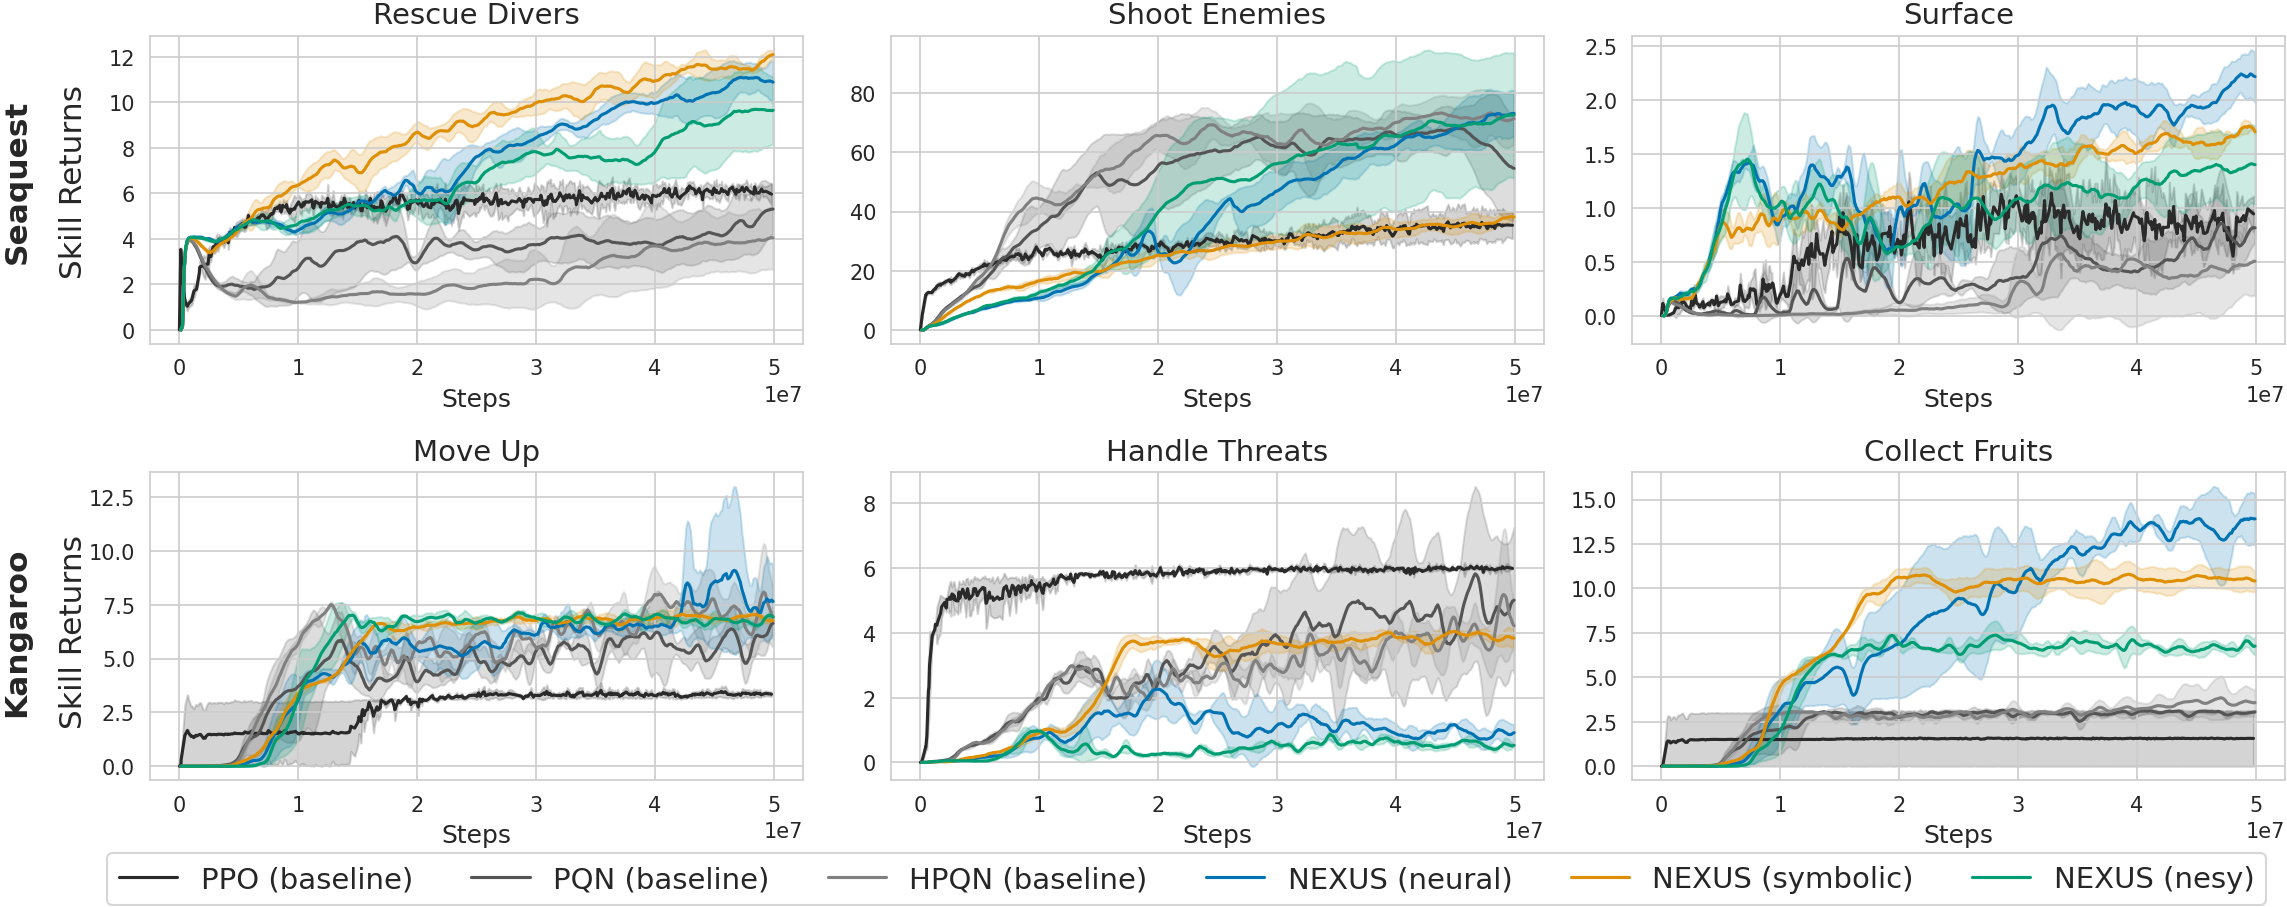

pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2


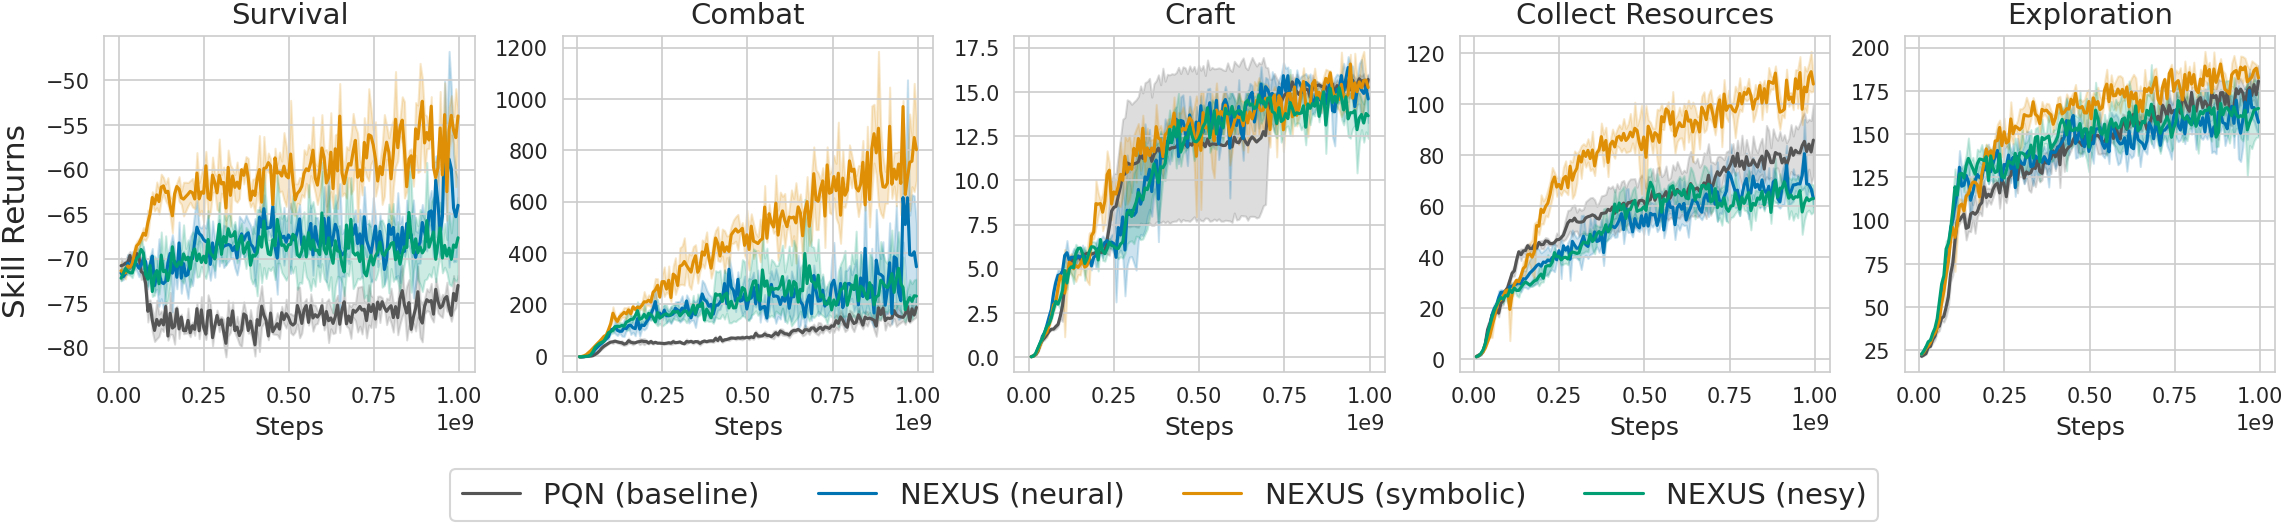

pqn_hier_pong
0
pqn_hier_llm_pong
1
pqn_hier_comb_pong
2
pqn_hier_pong
0
pqn_hier_llm_pong
1
pqn_hier_comb_pong
2
pqn_hier_pong
0
pqn_hier_llm_pong
1
pqn_hier_comb_pong
2
pqn_hier_breakout
0
pqn_hier_llm_breakout
1
pqn_hier_comb_breakout
2
pqn_hier_breakout
0
pqn_hier_llm_breakout
1
pqn_hier_comb_breakout
2
pqn_hier_breakout
0
pqn_hier_llm_breakout
1
pqn_hier_comb_breakout
2
pqn_hier_freeway
0
pqn_hier_llm_freeway
1
pqn_hier_comb_freeway
2
pqn_hier_freeway
0
pqn_hier_llm_freeway
1
pqn_hier_comb_freeway
2


/tmp/ipykernel_2665943/4231603483.py:160: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


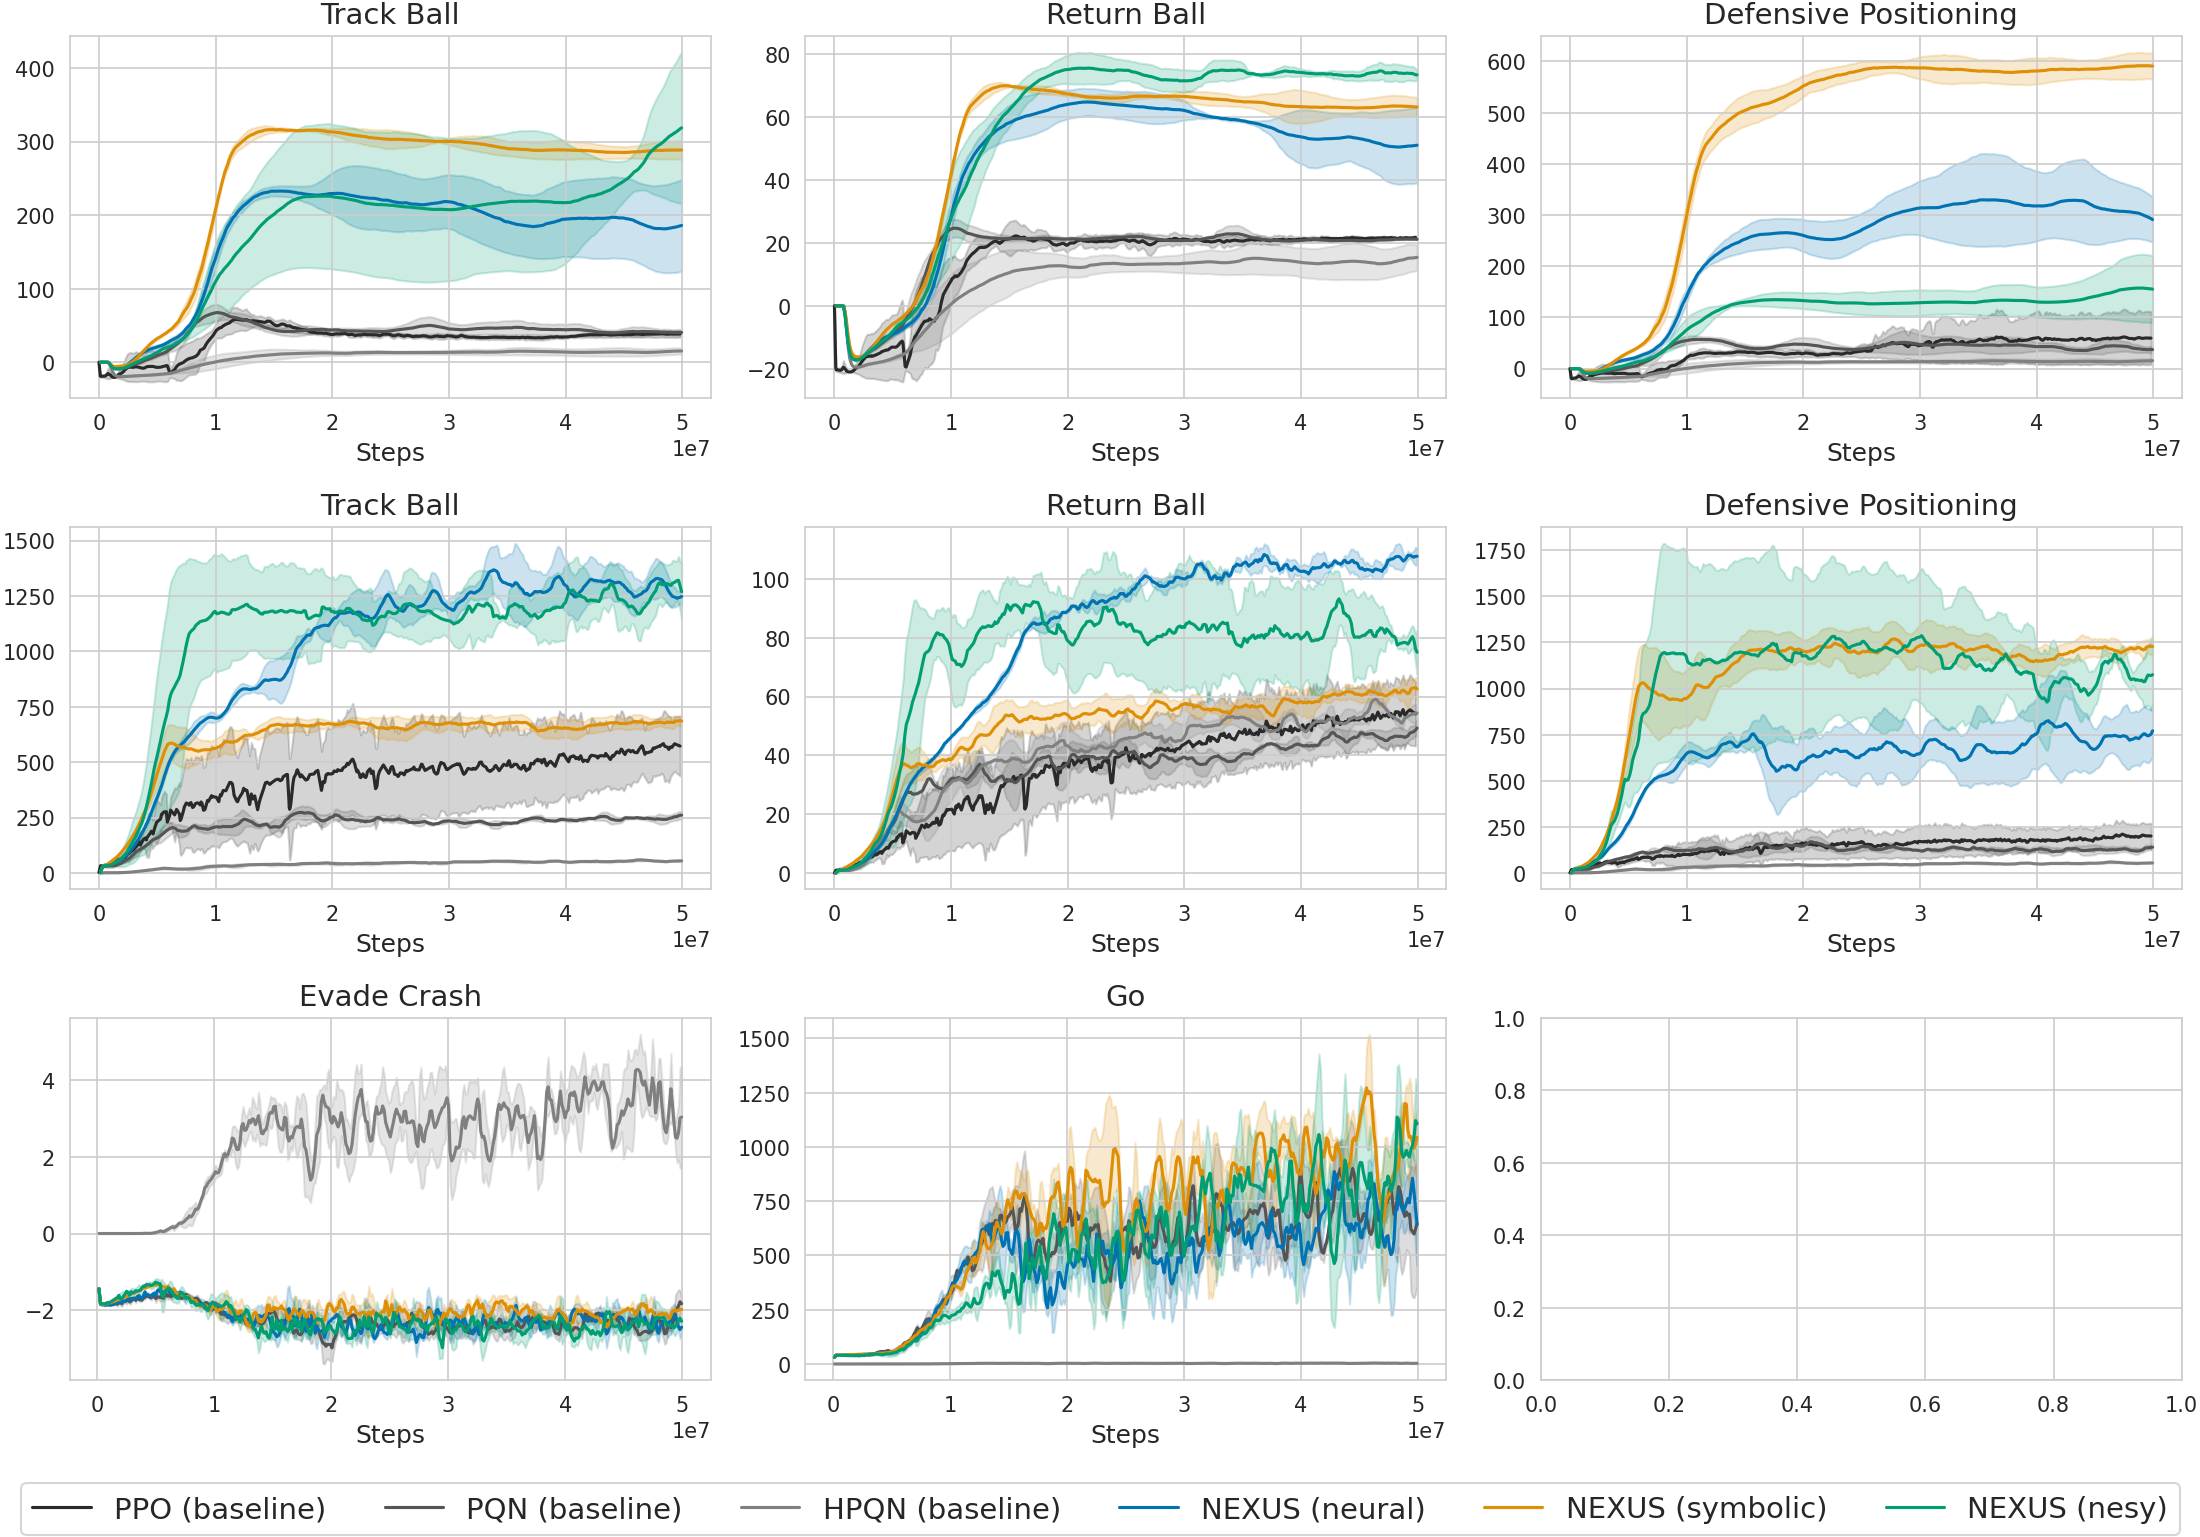

In [38]:

def single_reward_plot(game_data, algos, reward_row, ax, opt_name):
    # plot the reward (e.g. collect_divers) of all algos
    # sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    # gray_palette = ["#d9d9d9", "#bdbdbd", "#969696"]  # light to dark grays
    # gray_palette = ["#969696", "#737373", "#525252"]  # progressively darker
    baselines = ['PPO (baseline)', 'PQN (baseline)', 'HPQN (baseline)', 'Nudge (baseline)', 'BlendRL (baseline)']
    non_baselines = [algo for algo in algos if get_algorithm_from_name(algo) not in baselines]
    # colors = sns.color_palette("crest", n_colors=len(non_baselines))  # use a color palette for non-baselines
    colors_baseline = sns.color_palette("gray", n_colors=len(baselines))  # use a gray palette for baselines
    # with plt.rc_context(bundles.neurips2024(usetex=False)):
        # fig, ax = plt.subplots()
    for algo in algos:
        alg = algo
        # if "pqn_hier_comb" in algo and game_data["run_name"].str.contains("Craft").any():
        #     alg = "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"
        row = game_data[game_data["run_name"] == alg].iloc[0]
        x_data = row["x_data"]
        means = np.nanmean(row[f"{reward_row}_ret"], axis=0)
        stds = np.nanstd(row[f"{reward_row}_ret"], axis=0)
        # rescale
        # means = (means - np.nanmin(means)) / (np.nanmax(means) - np.nanmin(means) + 1e-8)
        # stds = (stds - np.nanmin(stds)) / (np.nanmax(stds) - np.nanmin(stds) + 1e-8)
        x_data = x_data[:len(means)]
        alg_label = get_algorithm_from_name(algo)
        if alg_label in baselines:
            # make gray
            color = colors_baseline[baselines.index(alg_label)]
        else:
            print(alg)
            print(non_baselines.index(alg))
            color = colors[non_baselines.index(alg)]
            # alg_label = alg_label + " (ours)"
        ax.plot(x_data, means, label=alg_label, color=color, zorder=1)
        ax.fill_between(x_data, means - stds, means + stds, color=color, alpha=0.2, zorder=0)
        ax.set_title(f"{opt_name}")
    ax.set_xlabel("Steps")
    # ax.legend()

def multi_reward_plot(df, opt_names, axes):
    # plot all single_reward_plots for all envs
    game_name = df["run_name"].iloc[0].split("_")[-1]
    # opts = ["opt0", "opt1", "opt2"]
    opts = ["opt3", "opt4", "opt5"]
    if "sea" in game_name:
        opts = ["opt4", "opt5", "opt6"]
    if "craft" in game_name:
        opts = ["opt0", "opt1", "opt2", "opt3", "opt4"]
    if "freeway" in game_name:
        opts = ["opt0", "opt1"]
    if "breakout" in game_name:
        opts = ["opt0", "opt1", "opt2"]
    if "pong" in game_name:
        opts = ["opt0", "opt1", "opt2"]
    for i, opt in enumerate(opts):
        if "craft" in game_name:
            # single_reward_plot(df, [f"pqn_rnn_{game_name}", f"pqn_rnn_hier_baseline_{game_name}", f"pqn_rnn_hier_{game_name}", f"pqn_rnn_hier_llm_{game_name}", f"pqn_rnn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])
            single_reward_plot(df, [f"pqn_rnn_{game_name}", f"pqn_rnn_hier_{game_name}", f"pqn_rnn_hier_llm_{game_name}", f"pqn_rnn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])
        elif "freeway" in game_name:
            single_reward_plot(df, [f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])
        else:
            single_reward_plot(df, [f"ppo_{game_name}", f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    # **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    fig, axs = plt.subplots(2, 3, figsize=(15, 6))
    seaquest_opt_names = ["Rescue Divers", "Shoot Enemies", "Surface"]
    kangaroo_opt_names = ["Move Up", "Handle Threats", "Collect Fruits"]
    multi_reward_plot(seaquest_df, seaquest_opt_names, axs[0])
    multi_reward_plot(kangaroo_df, kangaroo_opt_names, axs[1]) 

    # Create shared legend
    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.05))
    # Shared y-axis label
    # fig.text(0.04, 0.5, "Skill Rewards", va="center", rotation="vertical", fontsize=13)
    # fig.supylabel("Skill Rewards", x=0.01, fontsize=15, fontweight="bold")
    # One y-label for the first row (Seaquest)
    fig.text(
        0.005,                                    # x position (close to axes)
        0.77,
        "Skill Returns",
        va="center", ha="center", rotation="vertical",
        fontsize=15
    )

    # One y-label for the second row (Kangaroo)
    fig.text(
        0.005,
        0.27, 
        "Skill Returns",
        va="center", ha="center", rotation="vertical",
        fontsize=15
    )

    fig.text(-0.02, 0.77, "Seaquest", va='center', ha='center', rotation='vertical', fontsize=15, fontweight='bold')
    fig.text(-0.02, 0.27, "Kangaroo", va='center', ha='center', rotation='vertical', fontsize=15, fontweight='bold')
    fig.tight_layout()
    fig.savefig("multi_reward_plot_seaquest_kangaroo.pdf", bbox_inches="tight")
    fig.savefig("multi_reward_plot_seaquest_kangaroo.svg", bbox_inches="tight")
    plt.show()

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    # **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    # Craftax as separate plot
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))
    craftax_opt_names = ["Survival", "Combat", "Craft", "Collect Resources", "Exploration"]
    multi_reward_plot(craftax_df, craftax_opt_names, axs)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.20))
    fig.text(
        -0.01,
        0.5, 
        "Skill Returns",
        va="center", ha="center", rotation="vertical",
        fontsize=15
    )
    plt.savefig("multi_reward_plot_craftax.pdf", bbox_inches="tight")
    plt.show()

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    # **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    # Remaining as separate plot
    breakout_opt_names = ["Track Ball", "Return Ball", "Defensive Positioning"]
    pong_opt_names = ["Track Ball", "Return Ball", "Defensive Positioning"]
    freeway_opt_names = ["Evade Crash", "Go"]
    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    multi_reward_plot(pong_df, pong_opt_names, axs[0]) 
    multi_reward_plot(breakout_df, breakout_opt_names, axs[1])
    multi_reward_plot(freeway_df, freeway_opt_names, axs[2]) 
    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout()
    plt.savefig("multi_reward_plot_rest.pdf", bbox_inches="tight")
    plt.show()


In [136]:
def single_reward_comparison(game_data, algos, opt_names, reward_rows, ax):
    """
    Grouped bar chart comparing final rewards across methods for each option/skill.
    
    game_data : DataFrame with columns like opt0_ret, opt1_ret, etc.
    algos    : list of run_name strings (e.g. ["pqn_hier_kangaroo", "pqn_hier_llm_kangaroo"])
    opt_names: list of display labels for each option (e.g. ["Move Up", "Handle Threats"])
    reward_rows: list of column-key strings (e.g. ["opt0", "opt1", "opt2"])
    ax       : matplotlib Axes
    """
    colors = sns.color_palette("colorblind")
    gray_palette = sns.color_palette("Greys", n_colors=4)
    baselines = ['PPO (baseline)', 'PQN (baseline)', 'HPQN (baseline)', 'Nudge (baseline)', 'BlendRL (baseline)']
    non_baselines = [algo for algo in algos if get_algorithm_from_name(algo) not in baselines]

    n_opts = len(opt_names)
    n_algos = len(algos)

    # First pass: collect all means for normalization
    all_means = np.zeros((n_algos, n_opts))
    all_stds = np.zeros((n_algos, n_opts))
    for i, algo in enumerate(algos):
        row = game_data[game_data["run_name"] == algo].iloc[0]
        for j, reward_row in enumerate(reward_rows):
            col = f"{reward_row}_ret"
            # Shape: (num_seeds, num_steps) — take last non-NaN along steps axis
            data = row[col]
            # Find last non-NaN index per seed
            final_vals = np.array([seed_data[~np.isnan(seed_data)][-1] if np.any(~np.isnan(seed_data)) else np.nan for seed_data in data])
            all_means[i, j] = np.nanmean(final_vals)
            all_stds[i, j] = np.nanstd(final_vals)
    # Debug: print raw final values before normalization
    for i, algo in enumerate(algos):
        print(f"{algo}: means={all_means[i]}, stds={all_stds[i]}")

    # Min-max normalize each option so the best is 1.0 and worst is 0.0
    min_per_opt = np.nanmin(all_means, axis=0)
    range_per_opt = np.nanmax(all_means, axis=0) - min_per_opt
    range_per_opt = np.where(range_per_opt == 0, 1.0, range_per_opt)  # avoid division by zero
    all_means = (all_means - min_per_opt) / range_per_opt
    all_stds = all_stds / range_per_opt  # std scales the same way as the shifted+scaled data
    # Second pass: plot
    x = np.arange(n_opts)
    width = 0.8 / n_algos
    for i, algo in enumerate(algos):
        alg_label = get_algorithm_from_name(algo)
        if alg_label in baselines:
            color = gray_palette[baselines.index(alg_label) % len(gray_palette)]
        else:
            color = colors[non_baselines.index(algo) % len(colors)]

        offset = (i - n_algos / 2) * width + width / 2
        bars = ax.bar(x + offset, all_means[i], width, label=alg_label, color=color, zorder=2)
        ax.errorbar(x + offset, all_means[i], yerr=np.nan_to_num(all_stds[i], nan=0.0), fmt='none', ecolor='black', capsize=2, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(opt_names)
    ax.set_ylabel("Normalized Reward")
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.set_title("Normalized final reward per skill across methods")


ppo_seaquest: means=[ 5.96539307 35.37660726  0.94376628], stds=[0.4667303  4.5403939  0.16463975]
pqn_seaquest: means=[ 5.30829875 54.59541066  0.81501007], stds=[ 1.06061294 17.51592531  0.12701645]
pqn_hier_baseline_seaquest: means=[ 4.0426534  71.39734141  0.50456492], stds=[1.3977939  8.55202239 0.31978953]
pqn_hier_seaquest: means=[10.88936615 73.15952555  2.21651713], stds=[0.93243543 7.80872343 0.23664034]
pqn_hier_llm_seaquest: means=[12.09387461 38.12239838  1.70586141], stds=[0.18942598 1.53443638 0.02605356]
pqn_hier_comb_seaquest: means=[ 9.64871216 72.6183548   1.40000916], stds=[ 1.45862004 21.19149482  0.36364834]
ppo_kangaroo: means=[3.34225464 5.99420166 1.5619812 ], stds=[0.10623169 0.00201416 1.5619812 ]
pqn_kangaroo: means=[6.63362122 5.01293182 3.05189006], stds=[0.55535723 2.25227554 0.01081263]
pqn_hier_baseline_kangaroo: means=[6.9278539  4.21890259 3.57978566], stds=[1.39624897 0.74958124 0.7581719 ]
pqn_hier_kangaroo: means=[ 7.64905802  0.9176178  13.9119796

/tmp/ipykernel_177551/4203848023.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


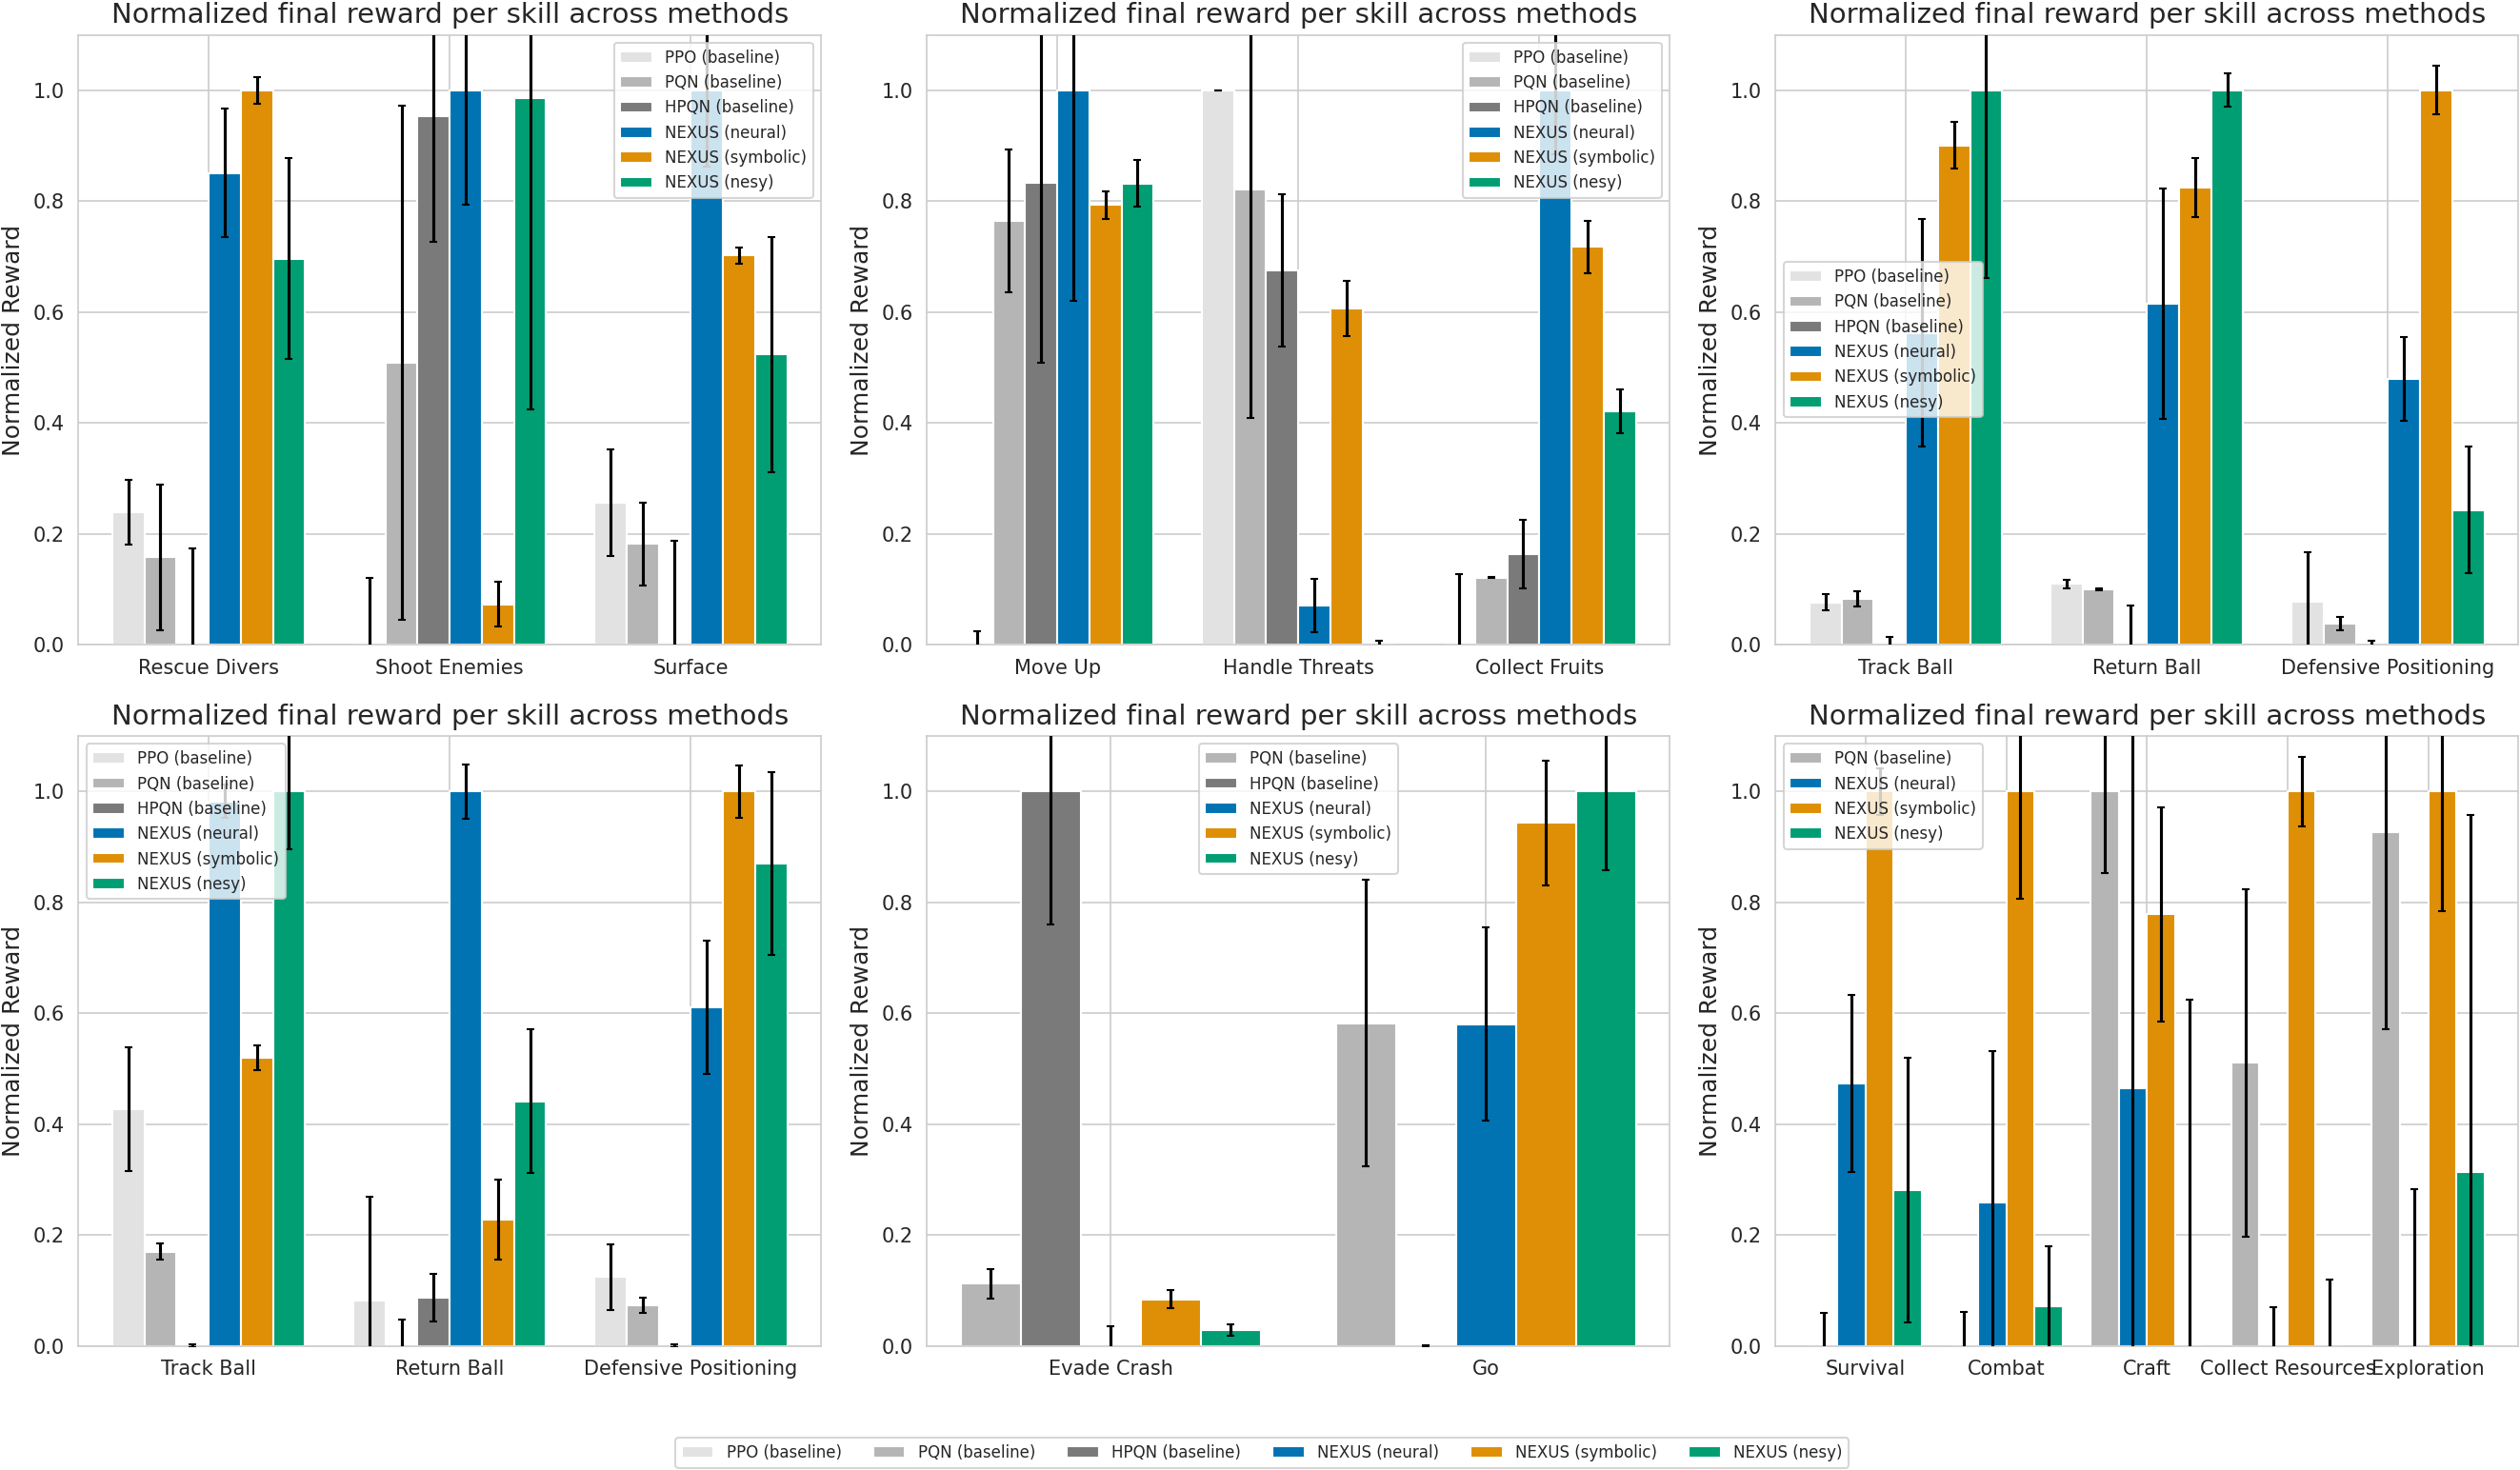

In [137]:
# Comparison bar charts of final skill rewards across methods
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))

    # === Seaquest ===
    game_name = "seaquest"
    seaquest_algos = [f"ppo_{game_name}", f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"]
    seaquest_opt_names = ["Rescue Divers", "Shoot Enemies", "Surface"]
    seaquest_reward_rows = ["opt4", "opt5", "opt6"]
    single_reward_comparison(seaquest_df, seaquest_algos, seaquest_opt_names, seaquest_reward_rows, axs[0, 0])

    # === Kangaroo ===
    game_name = "kangaroo"
    kangaroo_algos = [f"ppo_{game_name}", f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"]
    kangaroo_opt_names = ["Move Up", "Handle Threats", "Collect Fruits"]
    kangaroo_reward_rows = ["opt3", "opt4", "opt5"]
    single_reward_comparison(kangaroo_df, kangaroo_algos, kangaroo_opt_names, kangaroo_reward_rows, axs[0, 1])

    # === Pong ===
    game_name = "pong"
    pong_algos = [f"ppo_{game_name}", f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"]
    pong_opt_names = ["Track Ball", "Return Ball", "Defensive Positioning"]
    pong_reward_rows = ["opt0", "opt1", "opt2"]
    single_reward_comparison(pong_df, pong_algos, pong_opt_names, pong_reward_rows, axs[0, 2])

    # === Breakout ===
    game_name = "breakout"
    breakout_algos = [f"ppo_{game_name}", f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"]
    breakout_opt_names = ["Track Ball", "Return Ball", "Defensive Positioning"]
    breakout_reward_rows = ["opt0", "opt1", "opt2"]
    single_reward_comparison(breakout_df, breakout_algos, breakout_opt_names, breakout_reward_rows, axs[1, 0])

    # === Freeway ===
    game_name = "freeway"
    freeway_algos = [f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"]
    freeway_opt_names = ["Evade Crash", "Go"]
    freeway_reward_rows = ["opt0", "opt1"]
    single_reward_comparison(freeway_df, freeway_algos, freeway_opt_names, freeway_reward_rows, axs[1, 1])

    # === Craftax ===
    craftax_game = craftax_df["run_name"].iloc[0].split("_")[-1]
    craftax_algos = [f"pqn_rnn_{craftax_game}", f"pqn_rnn_hier_{craftax_game}", f"pqn_rnn_hier_llm_{craftax_game}", f"pqn_rnn_hier_comb_{craftax_game}"]
    craftax_opt_names = ["Survival", "Combat", "Craft", "Collect Resources", "Exploration"]
    craftax_reward_rows = ["opt0", "opt1", "opt2", "opt3", "opt4"]
    single_reward_comparison(craftax_df, craftax_algos, craftax_opt_names, craftax_reward_rows, axs[1, 2])

    # Shared legend at the bottom
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout()
    plt.savefig("single_reward_comparison.pdf", bbox_inches="tight")
    plt.savefig("single_reward_comparison.svg", bbox_inches="tight")
    plt.show()


In [138]:
def dual_metric_plot(df, game_name, algos, ax, modified=False):
    colors = sns.color_palette("colorblind")
    pastels = sns.color_palette("pastel")
    baselines = ["ppo", "pqn", "pqn_hier_baseline", "nudge", "blendrl"] 
    bar_colors_hns = []
    bar_colors_comp = []
    for algo in algos:
        if algo in baselines:
            # bar_colors_hns.append("lightgray")  # for HNS bars
            # bar_colors_comp.append("gray")      # for completeness bars
            bar_colors_hns.append(pastels[0])  # for HNS barn
            bar_colors_comp.append(pastels[1])      # for completeness bars
        else:
            bar_colors_hns.append(colors[0])    # method/ablations
            bar_colors_comp.append(colors[1])
    base_game = lambda g: g.split("_")[0].lower()
    random_score, human_score = human_random_performance[base_game(game_name)]

    ax2 = ax.twinx()

    hns_vals, comp_vals = [], []
    hns_modif_vals, comp_modif_vals = [], []
    hns_std, hns_modif_std, comp_std, comp_modif_std = [], [], [], []

    for i, algo in enumerate(algos):
        row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]
        # HNS
        # find argmax of time step across all seeds (axis=0)
        mean_ret = np.nanmean(row["test_env_ret"], axis=0)
        std_ret = np.nanstd(row["test_env_ret"], axis=0)
        max_hns_idx = mean_ret.argmax()
        print("Max idx: ", max_hns_idx)
        print("mean ret: ", mean_ret.shape)
        hns = (mean_ret[max_hns_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_stds = std_ret[max_hns_idx] / (human_score - random_score + 1e-8)  # normalize by human score

        mean_modif = np.nanmean(row["modif_test_env_ret"], axis=0)
        std_modif = np.nanstd(row["modif_test_env_ret"], axis=0)
        # max_hns_modif_idx = mean_modif.argmax()
        max_hns_modif_idx = max_hns_idx
        hns_modif = (mean_modif[max_hns_modif_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_modif_stds = std_modif[max_hns_modif_idx] / (human_score - random_score + 1e-8)  # normalize by human score
        # Do not use hns anymore - instead provide Game Reward
        # hns_vals.append(hns)
        # hns_modif_vals.append(hns_modif)
        # hns_std.append(hns_stds)
        # hns_modif_std.append(hns_modif_stds)
        hns_vals.append(mean_ret[max_hns_idx])
        hns_modif_vals.append(mean_modif[max_hns_modif_idx])
        hns_std.append(std_ret[max_hns_idx])
        hns_modif_std.append(std_modif[max_hns_modif_idx])


        # Completeness or Divers Rescued
        if game_name == "Kangaroo":
            mean_comp = np.nanmean(row["test_opt3_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt3_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt3_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt3_ret"], axis=0)
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            comp = (mean_comp[max_comp_idx]/9)*100 #/3 (for lives), /3 (for 3 platform levels)
            comp_modif = (mean_modif_comp[max_modif_comp_idx]/9)*100
            print(algo, mean_comp[max_comp_idx], mean_modif_comp[max_modif_comp_idx])
            comp_stds = std_comp[max_comp_idx] / 9 *100
            comp_modif_stds = std_modif_comp[max_modif_comp_idx] / 9 *100

            def compute_corrected_std(all_max_comps):
                all_adjusted_comps = []
                for val in all_max_comps:
                    if val / 3 > 3:
                        platforms_level_2 = (val / 3) - 3
                        equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                        adjusted = 100 + equiv*100 # as prob (not in %)
                        all_adjusted_comps.append(adjusted)
                    else:
                        all_adjusted_comps.append(val/9*100)
                print("all adjusted: ", all_adjusted_comps)
                comp_stds = np.std(all_adjusted_comps)
                return comp_stds

            # Correcting runs where platform is reached and then goes down ladder and back up -> artificially high values
            # Checked game footage for the following game finish percentages
            # checked all seeds (3 runs)
            if algo == "pqn_hier_llm":
                comp = (60+68+67) / 3 #reaches platform 2 in all 3 cases 
                comp_modif = (33+66+66)/3 #reaches platform 2 in 2 cases, else just 1
                comp_stds = np.std([60, 68, 67])
                comp_modif_stds = np.std([33, 66, 66]) 
            elif algo == "nudge":
                print("Manual correction for nudge")
                # if algo == "pqn_hier_llm":
                comp = (100+130+100) / 3 # reaches lvl2 in all 3 cases
                comp_modif = (100+100+105) / 3 # reaches lvl2 in all 3 cases
                comp_stds = np.std([100, 130, 100])
                comp_modif_stds = np.std([100, 100, 105])
            elif algo == "blendrl":
                print("Manual correction for blendrl")
                comp = (105+100+100) / 3 # reaches lvl2 in all 3 cases
                comp_modif = (150+100+105) / 3 # reaches lvl2 in all 3 cases
                comp_stds = np.std([105, 100, 100])
                comp_modif_stds = np.std([150, 100, 105])
            else: # all other runs look okay
                # It looks like it would also be the case for comb, but one of the seeds actually reaches level2 !!
                # so more than 100% is possible 
                # problem is that lvl 2 has 6 small platforms before reaching a level1 equivalent
                # so subtract 6, if reaching level 2
                if mean_comp[max_comp_idx] / 3 > 3: # reached lvl2 (/3 for num_lives)
                    platforms_level_2 = (mean_comp[max_comp_idx] / 3) - 3 #everything higher than the 3 lvl1 platforms (3 lives)
                    # divide by 6 to reach level1 equivalent (since 6 platforms in lvl2 equal 1 platform in lvl3)
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    # 100 for lvl1 + x% for lvl2
                    comp = 100 + equiv * 100
                    all_max_comps = row["test_opt3_ret"][:, max_comp_idx]
                    comp_stds = compute_corrected_std(all_max_comps)

                if mean_modif_comp[max_modif_comp_idx] / 3 > 3:
                    platforms_level_2 = (mean_modif_comp[max_modif_comp_idx] / 3) - 3
                    # divide by 6 to reach level1 equivalent
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    comp_modif = 100 + equiv * 100
                    all_max_modif_comps = row["modif_test_opt3_ret"][:, max_modif_comp_idx]
                    comp_modif_stds = compute_corrected_std(all_max_modif_comps)

        elif game_name == "Seaquest":
            mean_comp = np.nanmean(row["test_opt4_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt4_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt4_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt4_ret"], axis=0)
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            comp = mean_comp[max_comp_idx]
            comp_modif = mean_modif_comp[max_modif_comp_idx]
            comp_stds = std_comp[max_comp_idx]
            comp_modif_stds = std_modif_comp[max_modif_comp_idx]
        comp_vals.append(comp)
        comp_modif_vals.append(comp_modif)
        comp_std.append(comp_stds)
        comp_modif_std.append(comp_modif_stds)

    if modified:
        hns_vals = hns_modif_vals
        comp_vals = comp_modif_vals
        hns_std = hns_modif_std
        comp_std = comp_modif_std
    # Plot HNS
    # ax.bar(np.arange(len(algos)) - 0.2, hns_vals, yerr=hns_std, width=0.4, label="HNS", color=colors[0])
    ax.bar(np.arange(len(algos)) - 0.2, hns_vals, yerr=hns_std, width=0.4, label="HNS", color=bar_colors_hns)
    ax.set_ylabel("Game Reward", color=colors[0], fontweight='bold')
    ax.tick_params(axis='y', labelcolor=colors[0])

    # Plot Completeness / Divers
    # ax2.bar(np.arange(len(algos)) + 0.2, comp_vals, yerr=comp_std, width=0.4, 
    #         label="% level completed" if game_name == "Kangaroo" else "Divers Rescued", 
    #         color=colors[1])
    ax2.bar(np.arange(len(algos)) + 0.2, comp_vals, yerr=comp_std, width=0.4, 
            label="Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued", 
            color=bar_colors_comp)
    ax2.set_ylabel("Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued", color=colors[1], fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=colors[1])
    ax.set_xticks(np.arange(len(algos)))
    ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])#, rotation=30, ha='right')

    import matplotlib.transforms as mtransforms

    labels = ax.get_xticklabels()
    # offset = -5  # negative moves left, positive moves right (in points)
    offset = 15  # negative moves left, positive moves right (in points)
    for label in labels:
        label.set_rotation(30)
        label.set_ha('right')  # or 'center'
        # label.set_transform(label.get_transform() + mtransforms.ScaledTranslation(offset/72, 0, ax.figure.dpi_scale_trans))


    ax.set_ylim(bottom=0)
    ax2.set_ylim(bottom=0)

    ax.set_title(game_name)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

Max idx:  425
mean ret:  (500,)
Max idx:  227
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  206
mean ret:  (500,)
ppo 3.0000001192092896 3.0
Max idx:  303
mean ret:  (381,)
pqn 3.00000007947286 2.0
Max idx:  379
mean ret:  (381,)
pqn_hier_baseline 4.666666746139526 3.0
Max idx:  379
mean ret:  (381,)
pqn_hier 6.0 3.6666666666666665
Max idx:  227
mean ret:  (381,)
pqn_hier_llm 6.853444576263428 8.797731717427572
Max idx:  265
mean ret:  (381,)
pqn_hier_comb 6.333333810170491 3.0


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

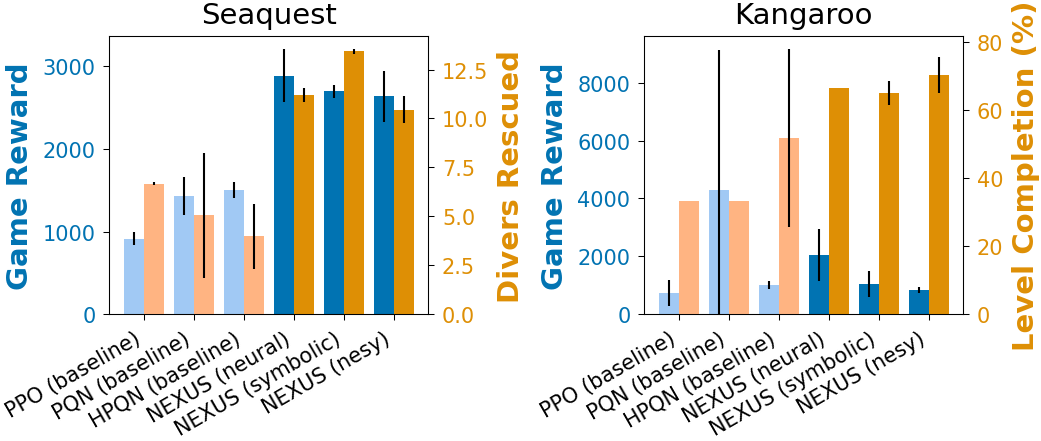

In [139]:
# non modified
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    # fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    dual_metric_plot(seaquest_df, "Seaquest", ["ppo", "pqn","pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0])
    dual_metric_plot(kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    # plt.tight_layout()
    plt.savefig("comparison_dual_metric.pdf", bbox_inches="tight")
    plt.savefig("comparison_dual_metric.svg", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

Max idx:  425
mean ret:  (500,)
Max idx:  227
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  206
mean ret:  (500,)
ppo 3.0000001192092896 3.0
Max idx:  303
mean ret:  (381,)
pqn 3.00000007947286 2.0
Max idx:  379
mean ret:  (381,)
pqn_hier_baseline 4.666666746139526 3.0
Max idx:  379
mean ret:  (381,)
pqn_hier 6.0 3.6666666666666665
Max idx:  227
mean ret:  (381,)
pqn_hier_llm 6.853444576263428 8.797731717427572
Max idx:  265
mean ret:  (381,)
pqn_hier_comb 6.333333810170491 3.0


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

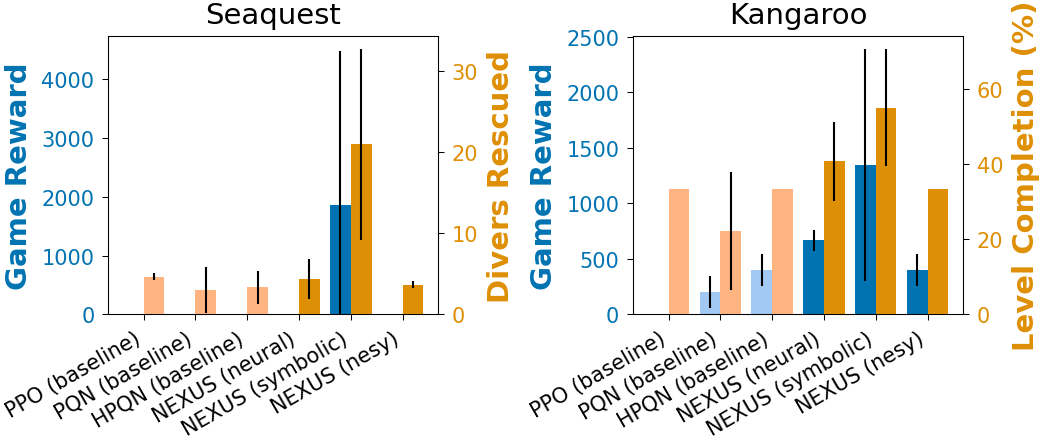

In [140]:
# modified
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    dual_metric_plot(seaquest_df, "Seaquest", ["ppo", "pqn", "pqn_hier_baseline","pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0], modified=True)
    dual_metric_plot(kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1], modified=True)
    # plt.tight_layout()
    plt.savefig("comparison_dual_metric_modif.pdf", bbox_inches="tight")
    plt.show()


/tmp/ipykernel_177551/320677702.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


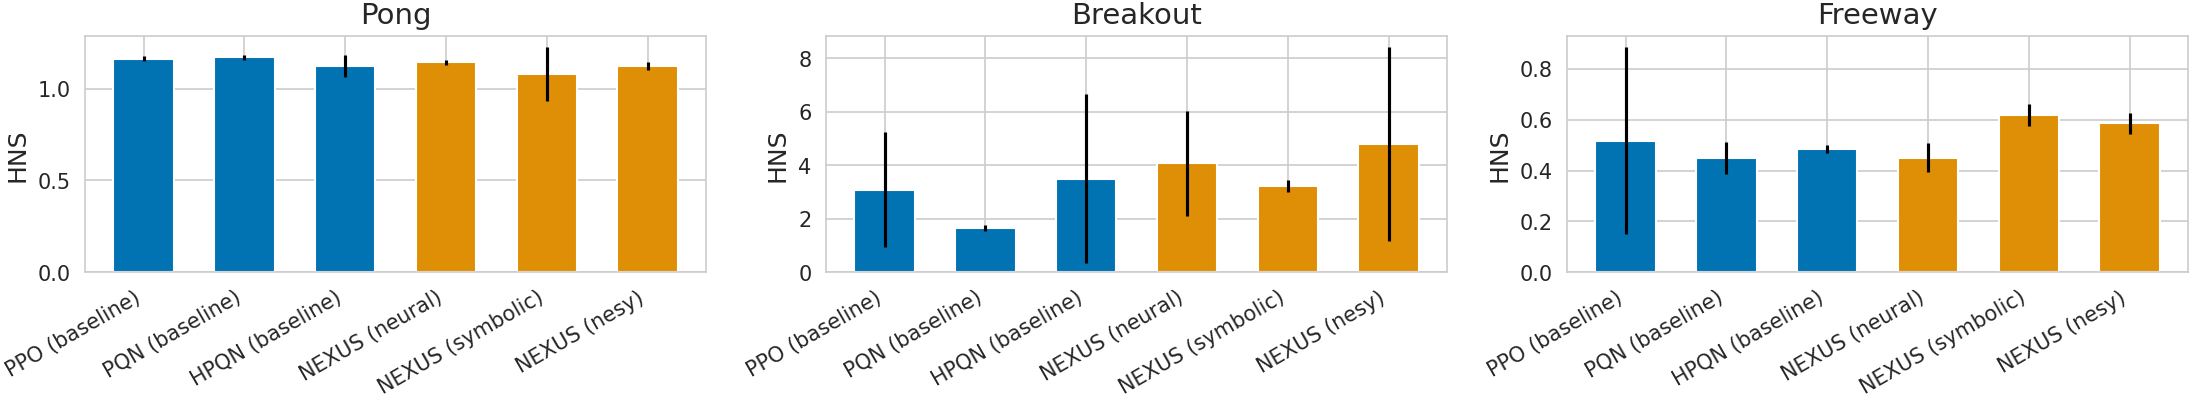

In [141]:
def single_metric_plot(df, game_name, algos, ax, modified=False):
    import seaborn as sns
    import numpy as np

    colors = sns.color_palette("colorblind")
    baselines = ["ppo", "pqn", "pqn_hier_baseline"]
    
    bar_colors = []
    for algo in algos:
        if algo in baselines:
            bar_colors.append(colors[0])
        else:
            bar_colors.append(colors[1])

    base_game = lambda g: g.split("_")[0].lower()
    random_score, human_score = human_random_performance[base_game(game_name)]

    hns_vals, hns_modif_vals = [], []
    hns_std, hns_modif_std = [], []

    for algo in algos:
        row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]

        mean_ret = np.nanmean(row["test_env_ret"], axis=0)
        std_ret = np.nanstd(row["test_env_ret"], axis=0)
        max_idx = mean_ret.argmax()
        hns = (mean_ret[max_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_std_val = std_ret[max_idx] / (human_score - random_score + 1e-8)

        mean_modif = np.nanmean(row["modif_test_env_ret"], axis=0)
        std_modif = np.nanstd(row["modif_test_env_ret"], axis=0)
        max_modif_idx = mean_modif.argmax()
        hns_modif = (mean_modif[max_modif_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_modif_std_val = std_modif[max_modif_idx] / (human_score - random_score + 1e-8)

        hns_vals.append(hns)
        hns_modif_vals.append(hns_modif)
        hns_std.append(hns_std_val)
        hns_modif_std.append(hns_modif_std_val)

    if modified:
        hns_vals = hns_modif_vals
        hns_std = hns_modif_std

    x = np.arange(len(algos))
    ax.bar(x, hns_vals, yerr=hns_std, width=0.6, color=bar_colors)
    ax.set_ylabel("HNS")
    ax.set_xticks(x)
    ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])
    ax.tick_params(axis='y')
    ax.set_ylim(bottom=0)
    ax.set_title(game_name)

    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    single_metric_plot(pong_df, "Pong", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0])
    single_metric_plot(breakout_df, "Breakout", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    single_metric_plot(freeway_df, "Freeway", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[2])
    handles, labels = ax[0].get_legend_handles_labels()
    plt.tight_layout()
    plt.savefig("comparison_single_metric.pdf", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

ppo 3.0000001192092896 3.0
pqn 3.00000007947286 2.0
pqn_hier_baseline 4.666666746139526 3.0
pqn_hier 6.0 3.6666666666666665
pqn_hier_llm 6.853444576263428 8.797731717427572
pqn_hier_comb 6.333333810170491 3.0
pqn_rnn 0.934587669163604
pqn_rnn_hier 1.152795933092917
pqn_rnn_hier_llm 1.1920998749477274
pqn_rnn_hier_comb 1.133315256744531


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

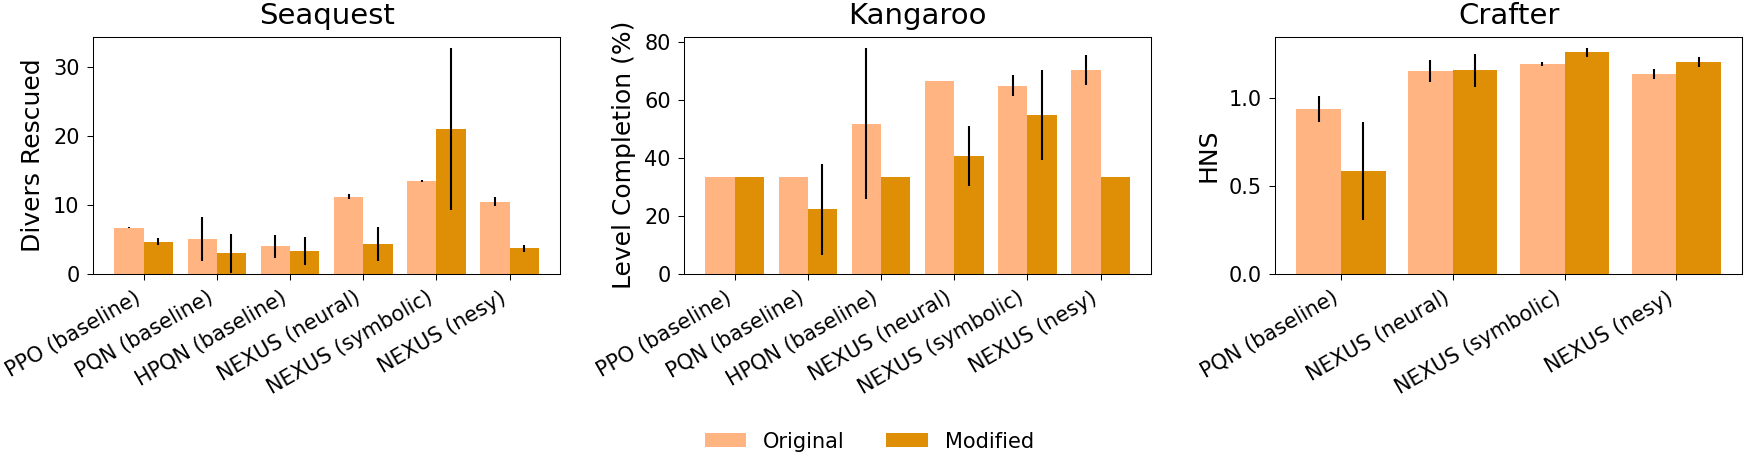

In [142]:
def aligned_performance_drop_plot(df, game_name, algos, ax):
    colors = sns.color_palette("colorblind")
    pastels = sns.color_palette("pastel")
    base_game = lambda g: g.split("_")[0].lower()
    random_score, human_score = human_random_performance[base_game(game_name)]

    hns_vals, comp_vals = [], []
    hns_modif_vals, comp_modif_vals = [], []
    hns_std, hns_modif_std, comp_std, comp_modif_std = [], [], [], []

    for i, algo in enumerate(algos):
        row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]
        # HNS
        # find argmax of time step across all seeds (axis=0)
        mean_ret = np.nanmean(row["test_env_ret"], axis=0)
        std_ret = np.nanstd(row["test_env_ret"], axis=0)
        max_hns_idx = mean_ret.argmax()
        hns = (mean_ret[max_hns_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_stds = std_ret[max_hns_idx] / (human_score - random_score + 1e-8)  # normalize by human score

        mean_modif = np.nanmean(row["modif_test_env_ret"], axis=0)
        std_modif = np.nanstd(row["modif_test_env_ret"], axis=0)
        # max_hns_modif_idx = mean_modif.argmax()
        max_hns_modif_idx = max_hns_idx
        hns_modif = (mean_modif[max_hns_modif_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_modif_stds = std_modif[max_hns_modif_idx] / (human_score - random_score + 1e-8)  # normalize by human score
        hns_vals.append(hns)
        hns_modif_vals.append(hns_modif)
        hns_std.append(hns_stds)
        hns_modif_std.append(hns_modif_stds)

        if game_name == "Craftax-Classic-Symbolic-v1":
            comp = hns
            print(algo, hns)
            comp_stds = hns_stds
            comp_modif = hns_modif
            comp_modif_stds = hns_modif_stds


        # Completeness or Divers Rescued
        if game_name == "Kangaroo":
            mean_comp = np.nanmean(row["test_opt3_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt3_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt3_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt3_ret"], axis=0)
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            comp = (mean_comp[max_comp_idx]/9)*100 #/3 (for lives), /3 (for 3 platform levels)
            comp_modif = (mean_modif_comp[max_modif_comp_idx]/9)*100
            print(algo, mean_comp[max_comp_idx], mean_modif_comp[max_modif_comp_idx])
            comp_stds = std_comp[max_comp_idx] / 9 *100
            comp_modif_stds = std_modif_comp[max_modif_comp_idx] / 9 *100

            def compute_corrected_std(all_max_comps):
                all_adjusted_comps = []
                for val in all_max_comps:
                    if val / 3 > 3:
                        platforms_level_2 = (val / 3) - 3
                        equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                        adjusted = 100 + equiv*100 # as prob (not in %)
                        all_adjusted_comps.append(adjusted)
                    else:
                        all_adjusted_comps.append(val/9*100)
                print("all adjusted: ", all_adjusted_comps)
                comp_stds = np.std(all_adjusted_comps)
                return comp_stds

            # Correcting runs where platform is reached and then goes down ladder and back up -> artificially high values
            # Checked game footage for the following game finish percentages
            # checked all seeds (3 runs)
            if algo == "pqn_hier_llm":
                comp = (60+68+67) / 3 #reaches platform 2 in all 3 cases 
                comp_modif = (33+66+66)/3 #reaches platform 2 in 2 cases, else just 1
                comp_stds = np.std([60, 68, 67])
                comp_modif_stds = np.std([33, 66, 66]) 
            elif algo == "nudge":
                print("Manual correction for nudge")
                # if algo == "pqn_hier_llm":
                comp = (100+130+100) / 3 # reaches lvl2 in all 3 cases
                comp_modif = (100+100+105) / 3 # reaches lvl2 in all 3 cases
                comp_stds = np.std([100, 130, 100])
                comp_modif_stds = np.std([100, 100, 105])
            elif algo == "blendrl":
                print("Manual correction for blendrl")
                comp = (105+100+100) / 3 # reaches lvl2 in all 3 cases
                comp_modif = (150+100+105) / 3 # reaches lvl2 in all 3 cases
                comp_stds = np.std([105, 100, 100])
                comp_modif_stds = np.std([150, 100, 105])
            else: # all other runs look okay
                # It looks like it would also be the case for comb, but one of the seeds actually reaches level2 !!
                # so more than 100% is possible 
                # problem is that lvl 2 has 6 small platforms before reaching a level1 equivalent
                # so subtract 6, if reaching level 2
                if mean_comp[max_comp_idx] / 3 > 3: # reached lvl2 (/3 for num_lives)
                    platforms_level_2 = (mean_comp[max_comp_idx] / 3) - 3 #everything higher than the 3 lvl1 platforms (3 lives)
                    # divide by 6 to reach level1 equivalent (since 6 platforms in lvl2 equal 1 platform in lvl3)
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    # 100 for lvl1 + x% for lvl2
                    comp = 100 + equiv * 100
                    all_max_comps = row["test_opt3_ret"][:, max_comp_idx]
                    comp_stds = compute_corrected_std(all_max_comps)

                if mean_modif_comp[max_modif_comp_idx] / 3 > 3:
                    platforms_level_2 = (mean_modif_comp[max_modif_comp_idx] / 3) - 3
                    # divide by 6 to reach level1 equivalent
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    comp_modif = 100 + equiv * 100
                    all_max_modif_comps = row["modif_test_opt3_ret"][:, max_modif_comp_idx]
                    comp_modif_stds = compute_corrected_std(all_max_modif_comps)

        elif game_name == "Seaquest":
            mean_comp = np.nanmean(row["test_opt4_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt4_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt4_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt4_ret"], axis=0)
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            comp = mean_comp[max_comp_idx]
            comp_modif = mean_modif_comp[max_modif_comp_idx]
            comp_stds = std_comp[max_comp_idx]
            comp_modif_stds = std_modif_comp[max_modif_comp_idx]
        comp_vals.append(comp)
        comp_modif_vals.append(comp_modif)
        comp_std.append(comp_stds)
        comp_modif_std.append(comp_modif_stds)

    # Plot Completeness / Divers
    ax.bar(np.arange(len(algos)) - 0.2, comp_vals, yerr=comp_std, width=0.4, 
            color=pastels[1])
    ax.bar(np.arange(len(algos)) + 0.2, comp_modif_vals, yerr=comp_modif_std, width=0.4, 
            color=colors[1])

    y_label = "HNS" if game_name == "Craftax-Classic-Symbolic-v1" else ("Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued")
    ax.set_ylabel(y_label)
    ax.set_xticks(np.arange(len(algos)))
    ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])#, rotation=30, ha='right')
    # add legend
    # ax.legend(["Original", "Modified"])

    ax.set_ylim(bottom=0)
    game_name = "Crafter" if game_name == "Craftax-Classic-Symbolic-v1" else game_name
    ax.set_title(game_name)
    
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')
    

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    b1 = aligned_performance_drop_plot(seaquest_df, "Seaquest", ["ppo", "pqn", "pqn_hier_baseline","pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0])
    b2 = aligned_performance_drop_plot(kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    b3 = aligned_performance_drop_plot(craftax_df, "Craftax-Classic-Symbolic-v1", ["pqn_rnn", "pqn_rnn_hier", "pqn_rnn_hier_llm", "pqn_rnn_hier_comb"], ax[2])
    fig.legend(labels=["Original", "Modified"], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.1)) 
    plt.tight_layout()
    plt.savefig("drop_plot.pdf", bbox_inches="tight")
    plt.show()

# Rebuttal stuff

/tmp/ipykernel_177551/1268891966.py:70: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Baselines:  ['hpqn', 'llm', 'comb']
Non baselines:  ['hpqn_2', 'llm_2', 'comb_2']
NEXUS (neural)
NEXUS (neural, noisy)
NEXUS (symbolic)
NEXUS (symbolic, noisy)
NEXUS (nesy)
NEXUS (nesy, noisy)


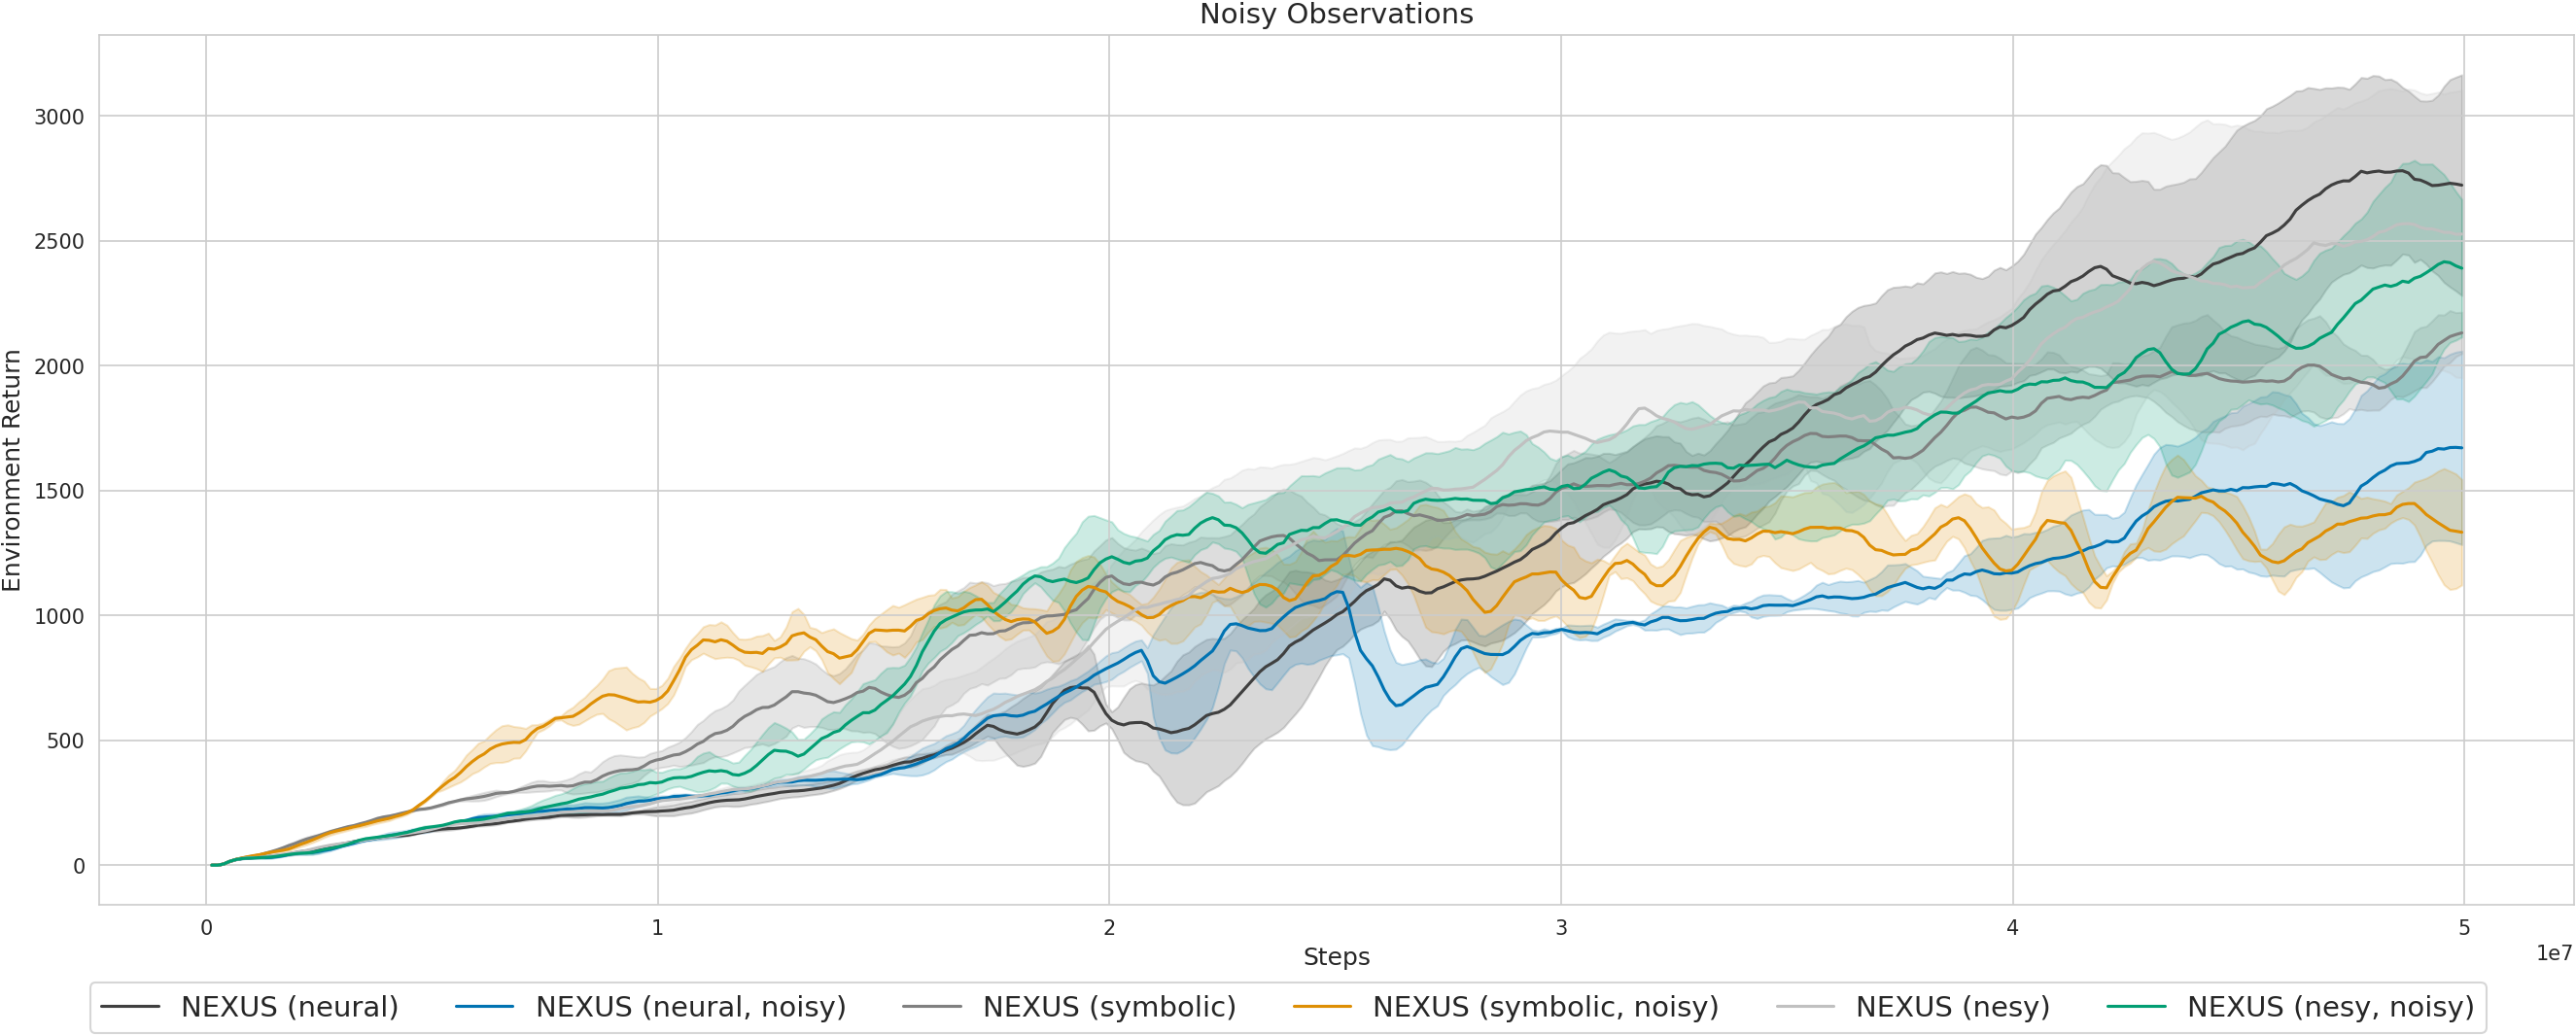

In [143]:
# 0: noisy_train, 0.9 prob ; 1: noisy_test, 0.9 prob ; 2: noisy_train, 0.95 prob ; 3: noisy_test, 0.95 prob
def algo_from_key(run_key):
    if run_key == "hpqn":
        return "NEXUS (neural)"
    elif run_key in ["hpqn_0", "hpqn_1", "hpqn_2", "hpqn_3"]: 
        return "NEXUS (neural, noisy)"
    elif run_key == "llm":
        return "NEXUS (symbolic)"
    elif run_key in ["llm_0", "llm_1", "llm_2", "llm_3"]: 
        return "NEXUS (symbolic, noisy)"
    elif run_key == "comb":
        return "NEXUS (nesy)"
    elif run_key in ["comb_0", "comb_1", "comb_2", "comb_3"]:
        return "NEXUS (nesy, noisy)"

def single_return_plot(game_data, algos, reward_row, ax, opt_name):
    # plot the return of all algos
    colors = sns.color_palette("colorblind")
    baselines = [algo for algo in algos if not ("_0" in algo or "_1" in algo or "_2" in algo or "_3" in algo)]
    print("Baselines: ", baselines)
    non_baselines = [algo for algo in algos if (algo not in baselines)]
    print("Non baselines: ", non_baselines)

    colors_baseline = sns.color_palette("gray", n_colors=len(baselines))  # use a gray palette for baselines

    for algo in algos:
        alg = algo
        row = game_data[game_data["run_key"] == alg].iloc[0]
        x_data = row["x_data"]
        means = np.nanmean(row[f"{reward_row}_ret"], axis=0)
        stds = np.nanstd(row[f"{reward_row}_ret"], axis=0)
        x_data = x_data[:len(means)]
        alg_label = algo_from_key(algo)
        if alg in baselines:
            # make gray
            color = colors_baseline[baselines.index(alg)]
        else:
            color = colors[non_baselines.index(alg)]
        print(alg_label)
        ax.plot(x_data, means, label=alg_label, color=color, zorder=1)
        ax.fill_between(x_data, means - stds, means + stds, color=color, alpha=0.2, zorder=0)
        ax.set_title(f"{opt_name}")
    ax.set_xlabel("Steps")

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    # **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    fig, axs = plt.subplots(1, 1, figsize=(18, 7))
    merged_seaquest_df = pd.concat([seaquest_df, noisy_seaquest_df])
    # merged_kangaroo_df = pd.concat([kangaroo_df, noisy_kangaroo_df]) 
    single_return_plot(merged_seaquest_df, ["hpqn", "hpqn_2", "llm", "llm_2", "comb", "comb_2"], "env", axs, "Noisy Observations")
    # single_return_plot(merged_kangaroo_df, ["hpqn", "hpqn_1", "llm", "llm_1", "comb", "comb_1"], "env", axs, "Noisy Observations")
    # single_return_plot(merged_kangaroo_df, ["pqn_hier_kangaroo", "pqn_hier_llm_kangaroo", "pqn_hier_comb_kangaroo"], "env", axs, "Noisy Observations")

    # Create shared legend
    handles, labels = axs.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.05))

    # Add y-axis label
    axs.set_ylabel("Environment Return")

    fig.tight_layout()
    plt.show()


In [144]:
from matplotlib.patches import Patch

def noisy_dual_metric_plot(df, game_name, algos, ax, modified=False):
    colors = sns.color_palette("colorblind")
    pastels = sns.color_palette("pastel")
    baselines = [algo for algo in algos if not ("_0" in algo or "_1" in algo or "_2" in algo or "_3" in algo)]
    bar_colors_hns = []
    bar_colors_comp = []
    for algo in algos:
        if algo in baselines:
            # bar_colors_hns.append("lightgray")  # for HNS bars
            # bar_colors_comp.append("gray")      # for completeness bars
            bar_colors_hns.append(pastels[0])  # for HNS barn
            bar_colors_comp.append(pastels[1])      # for completeness bars
        else:
            bar_colors_hns.append(colors[0])    # method/ablations
            bar_colors_comp.append(colors[1])
    base_game = lambda g: g.split("_")[0].lower()
    random_score, human_score = human_random_performance[base_game(game_name)]

    ax2 = ax.twinx()

    hns_vals, comp_vals = [], []
    hns_modif_vals, comp_modif_vals = [], []
    hns_std, hns_modif_std, comp_std, comp_modif_std = [], [], [], []

    for i, algo in enumerate(algos):
        # row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]
        print(algo)
        row = df[df["run_key"] == algo].iloc[0]
        # HNS
        # find argmax of time step across all seeds (axis=0)
        mean_ret = np.nanmean(row["test_env_ret"], axis=0)
        std_ret = np.nanstd(row["test_env_ret"], axis=0)
        max_hns_idx = mean_ret.argmax()
        hns = (mean_ret[max_hns_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_stds = std_ret[max_hns_idx] / (human_score - random_score + 1e-8)  # normalize by human score

        mean_modif = np.nanmean(row["modif_test_env_ret"], axis=0)
        std_modif = np.nanstd(row["modif_test_env_ret"], axis=0)
        # max_hns_modif_idx = mean_modif.argmax()
        max_hns_modif_idx = max_hns_idx
        hns_modif = (mean_modif[max_hns_modif_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_modif_stds = std_modif[max_hns_modif_idx] / (human_score - random_score + 1e-8)  # normalize by human score
        # Do not use hns anymore - instead provide Game Reward
        # hns_vals.append(hns)
        # hns_modif_vals.append(hns_modif)
        # hns_std.append(hns_stds)
        # hns_modif_std.append(hns_modif_stds)
        hns_vals.append(mean_ret[max_hns_idx])
        hns_modif_vals.append(mean_modif[max_hns_modif_idx])
        hns_std.append(std_ret[max_hns_idx])
        hns_modif_std.append(std_modif[max_hns_modif_idx])


        # Completeness or Divers Rescued
        if game_name == "Kangaroo":
            mean_comp = np.nanmean(row["test_opt3_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt3_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt3_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt3_ret"], axis=0)
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            comp = (mean_comp[max_comp_idx]/9)*100 #/3 (for lives), /3 (for 3 platform levels)
            comp_modif = (mean_modif_comp[max_modif_comp_idx]/9)*100
            comp_stds = std_comp[max_comp_idx] / 9 *100
            comp_modif_stds = std_modif_comp[max_modif_comp_idx] / 9 *100

            def compute_corrected_std(all_max_comps):
                all_adjusted_comps = []
                for val in all_max_comps:
                    if val / 3 > 3:
                        platforms_level_2 = (val / 3) - 3
                        equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                        adjusted = 100 + equiv*100 # as prob (not in %)
                        all_adjusted_comps.append(adjusted)
                    else:
                        all_adjusted_comps.append(val/9*100)
                print("all adjusted: ", all_adjusted_comps)
                comp_stds = np.std(all_adjusted_comps)
                return comp_stds

            # Correcting runs where platform is reached and then goes down ladder and back up -> artificially high values
            # Checked game footage for the following game finish percentages
            # checked all seeds (3 runs)
            # TODO: Is this still required?
            if algo == "llm":
                print("Manual correction for llm")
            # if algo == "pqn_hier_llm":
                comp = (60+68+67) / 3 #reaches platform 2 in all 3 cases 
                comp_modif = (33+66+66)/3 #reaches platform 2 in 2 cases, else just 1
                comp_stds = np.std([60, 68, 67])
                comp_modif_stds = np.std([33, 66, 66]) 
            else: # all other runs look okay
                # It looks like it would also be the case for comb, but one of the seeds actually reaches level2 !!
                # so more than 100% is possible 
                # problem is that lvl 2 has 6 small platforms before reaching a level1 equivalent
                # so subtract 6, if reaching level 2
                if mean_comp[max_comp_idx] / 3 > 3: # reached lvl2 (/3 for num_lives)
                    platforms_level_2 = (mean_comp[max_comp_idx] / 3) - 3 #everything higher than the 3 lvl1 platforms (3 lives)
                    # divide by 6 to reach level1 equivalent (since 6 platforms in lvl2 equal 1 platform in lvl3)
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    # 100 for lvl1 + x% for lvl2
                    comp = 100 + equiv * 100
                    all_max_comps = row["test_opt3_ret"][:, max_comp_idx]
                    comp_stds = compute_corrected_std(all_max_comps)

                if mean_modif_comp[max_modif_comp_idx] / 3 > 3:
                    platforms_level_2 = (mean_modif_comp[max_modif_comp_idx] / 3) - 3
                    # divide by 6 to reach level1 equivalent
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    comp_modif = 100 + equiv * 100
                    all_max_modif_comps = row["modif_test_opt3_ret"][:, max_modif_comp_idx]
                    comp_modif_stds = compute_corrected_std(all_max_modif_comps)

        elif game_name == "Seaquest":
            mean_comp = np.nanmean(row["test_opt4_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt4_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt4_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt4_ret"], axis=0)
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            comp = mean_comp[max_comp_idx]
            comp_modif = mean_modif_comp[max_modif_comp_idx]
            comp_stds = std_comp[max_comp_idx]
            comp_modif_stds = std_modif_comp[max_modif_comp_idx]
        comp_vals.append(comp)
        comp_modif_vals.append(comp_modif)
        comp_std.append(comp_stds)
        comp_modif_std.append(comp_modif_stds)

    if modified:
        hns_vals = hns_modif_vals
        comp_vals = comp_modif_vals
        hns_std = hns_modif_std
        comp_std = comp_modif_std

    # Change order of bars: want to always show original, then modified
    # currently, they are original_hns, original_comp; modified_hns, modified_comp (in two x-positions)
    # Want: original_hns, modified_hns, original_comp, modified_comp (in one x-position)
    # so arrange them together (interleaved)
    # -0,4: orig_hns, -0,2: noise_hns, +0,2: orig_comp, +0,4: noise_comp
    # Assuming they are ordered correctly, extract:
    orig_hns_vals = hns_vals[::2]
    noise_hns_vals = hns_vals[1::2]
    orig_comp_vals = comp_vals[::2]
    noise_comp_vals = comp_vals[1::2]
    orig_hns_std = hns_std[::2]
    noise_hns_std = hns_std[1::2]
    orig_comp_std = comp_std[::2]
    noise_comp_std = comp_std[1::2]

    # plot
    ax.bar(np.arange(len(orig_hns_vals)) - 0.3, orig_hns_vals, yerr=orig_hns_std, width=0.2, label="Original", color=colors[0], edgecolor='black')
    ax.bar(np.arange(len(noise_hns_vals))- 0.1, noise_hns_vals, yerr=noise_hns_std, width=0.2, label="Noisy", color=colors[0], hatch='///', edgecolor='black')
    ax2.bar(np.arange(len(orig_comp_vals)) + 0.1, orig_comp_vals, yerr=orig_comp_std, width=0.2, 
            label="Original", color=colors[1], edgecolor='black')
    ax2.bar(np.arange(len(noise_comp_vals))+0.3, noise_comp_vals, yerr=noise_comp_std, width=0.2, 
            label="Noisy", color=colors[1], hatch='///', edgecolor='black')



    # ax.bar(np.arange(len(algos)) - 0.2, hns_vals, yerr=hns_std, width=0.4, label="HNS", color=bar_colors_hns)
    ax.set_ylabel("Game Reward", color=colors[0], fontweight='bold')
    ax.tick_params(axis='y', labelcolor=colors[0])

    # ax2.bar(np.arange(len(algos)) + 0.2, comp_vals, yerr=comp_std, width=0.4, 
    #         label="Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued", 
    #         color=bar_colors_comp)
    ax2.set_ylabel("Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued", color=colors[1], fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=colors[1])
    # ax.set_xticks(np.arange(len(algos)))
    ax.set_xticks(np.arange(len(baselines)))
    ax.set_xticklabels([algo_from_key(a) for a in baselines])

    labels = ax.get_xticklabels()
    for label in labels:
        label.set_rotation(30)
        label.set_ha('right')  # or 'center'

    ax.set_ylim(bottom=0)
    ax2.set_ylim(bottom=0)

    legend_elements = [
        # 1. Explain the Colors
        Patch(facecolor=colors[0], edgecolor='black', label='Game Reward'),
        Patch(facecolor=colors[1], edgecolor='black', label='Alignment Score'),
        
        # 2. Explain the Hatching (make facecolor white/gray to highlight pattern)
        Patch(facecolor='white', edgecolor='black', label='Original'),
        Patch(facecolor='white', edgecolor='black', hatch='///', label='Noisy')
    ]

    ax.set_title(game_name)
    return legend_elements

hpqn
hpqn_2
llm
llm_2
comb
comb_2
hpqn
hpqn_2
all adjusted:  [np.float64(140.87749763771342), np.float64(33.34418402777778), np.float64(63.617547353108726)]
llm
Manual correction for llm
llm_2
all adjusted:  [np.float64(75.47774844699435), np.float64(104.53935375920048), np.float64(127.76091540301287)]
comb
comb_2
all adjusted:  [np.float64(95.77737384372287), np.float64(127.10153438426829), np.float64(166.14453351056136)]
all adjusted:  [np.float64(35.244981447855636), np.float64(33.33875868055556), np.float64(218.7303755018446)]


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

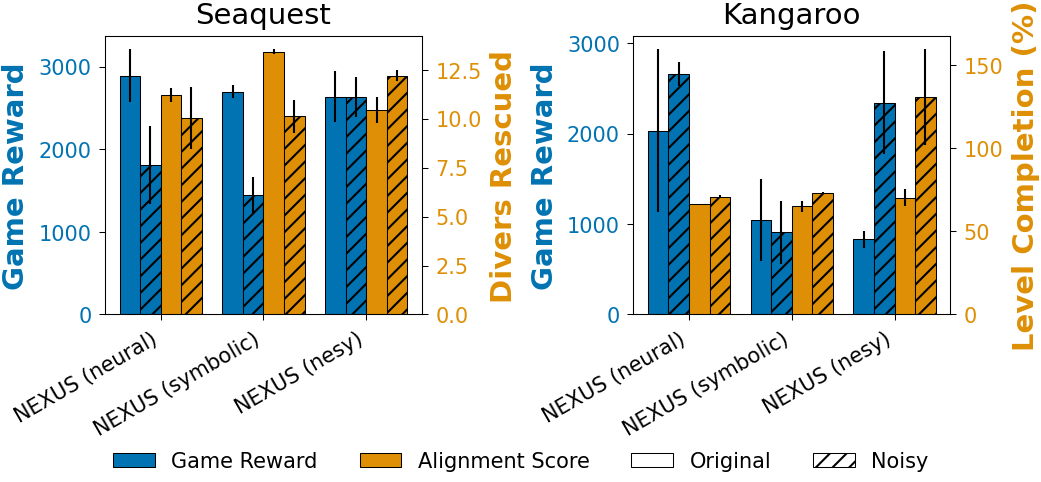

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

hpqn
hpqn_0
llm
llm_0
comb
comb_0
hpqn
hpqn_0
llm
Manual correction for llm
llm_0
all adjusted:  [np.float64(134.54365906892), np.float64(100.64659118652344), np.float64(100.42830573187933)]
comb
comb_0
all adjusted:  [np.float64(119.799154776114), np.float64(126.11596142804181), np.float64(145.51043333830657)]
all adjusted:  [np.float64(290.82891676161023), np.float64(577.6216295030382), np.float64(68.10276243421767)]


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

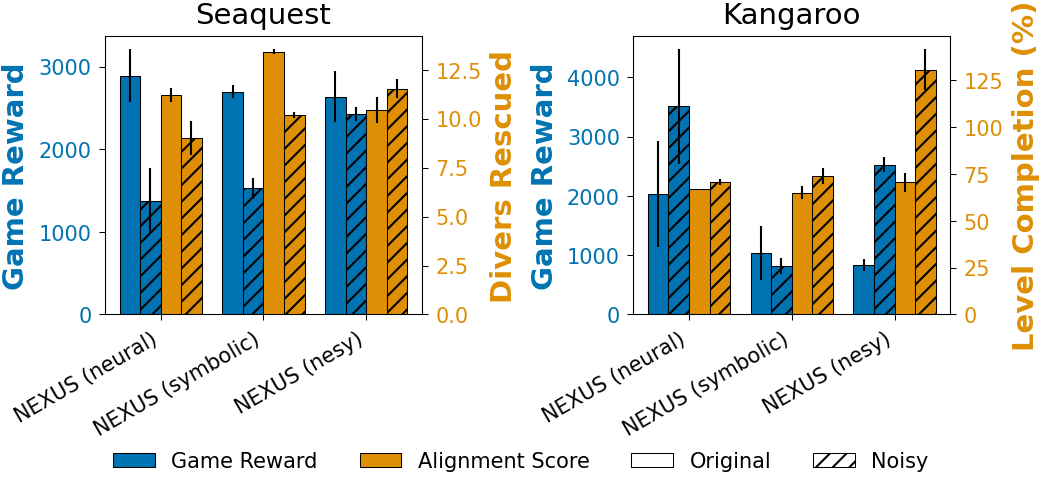

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

hpqn
hpqn_3
llm
llm_3
comb
comb_3
hpqn
hpqn_3
llm
Manual correction for llm
llm_3
all adjusted:  [np.float64(313.45277009186924), np.float64(657.2690045392072), np.float64(105.02140257093642)]
comb
comb_3
all adjusted:  [np.float64(185.06105917471427), np.float64(108.06710278546369), np.float64(150.7807413736979)]
all adjusted:  [np.float64(126.59053096064815), np.float64(77.52278645833334), np.float64(499.5776141131365)]


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

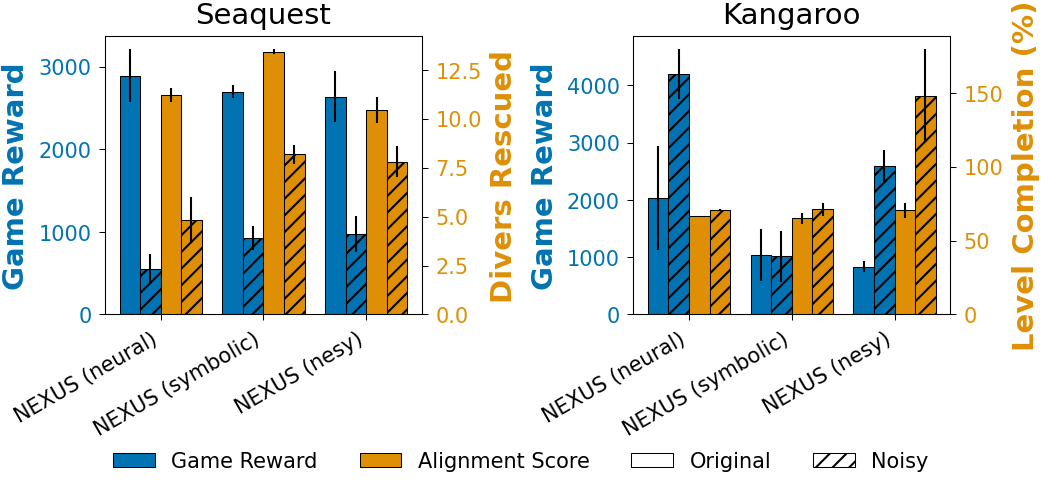

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

hpqn
hpqn_1
llm
llm_1
comb
comb_1
hpqn
hpqn_1
all adjusted:  [np.float64(141.98902977837457), np.float64(68.10668839348686), np.float64(104.70750243575485)]
llm
Manual correction for llm
llm_1
all adjusted:  [np.float64(49.42491319444444), np.float64(79.52901522318521), np.float64(202.56770098650895)]
comb
comb_1
all adjusted:  [np.float64(169.47923589635778), np.float64(187.76728312174478), np.float64(178.69966295030383)]
all adjusted:  [np.float64(302.3279543276186), np.float64(317.77017381456164), np.float64(70.45645713806152)]


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

In [145]:
# noisy training (5% misdetection prob)
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    # fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    merged_seaquest_df = pd.concat([seaquest_df, noisy_seaquest_df])
    legend_elements = noisy_dual_metric_plot(merged_seaquest_df, "Seaquest", ["hpqn", "hpqn_2", "llm", "llm_2", "comb", "comb_2"], ax[0])
    merged_kangaroo_df = pd.concat([kangaroo_df, noisy_kangaroo_df])
    noisy_dual_metric_plot(merged_kangaroo_df, "Kangaroo", ["hpqn", "hpqn_2", "llm", "llm_2", "comb", "comb_2"], ax[1])
    # plt.tight_layout()
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.1))
    plt.savefig("noisy5_comparison_dual_metric.pdf", bbox_inches="tight")
    plt.savefig("noisy5_comparison_dual_metric.svg", bbox_inches="tight")
    plt.show()

# noisy training (10% misdetection prob)
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    # fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    merged_seaquest_df = pd.concat([seaquest_df, noisy_seaquest_df])
    legend_elements = noisy_dual_metric_plot(merged_seaquest_df, "Seaquest", ["hpqn", "hpqn_0", "llm", "llm_0", "comb", "comb_0"], ax[0])
    merged_kangaroo_df = pd.concat([kangaroo_df, noisy_kangaroo_df])
    noisy_dual_metric_plot(merged_kangaroo_df, "Kangaroo", ["hpqn", "hpqn_0", "llm", "llm_0", "comb", "comb_0"], ax[1])
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.1))
    # plt.tight_layout()
    plt.savefig("noisy10_comparison_dual_metric.pdf", bbox_inches="tight")
    plt.savefig("noisy10_comparison_dual_metric.svg", bbox_inches="tight")
    plt.show()

# noisy eval (5% misdetection prob)
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    # fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    merged_seaquest_df = pd.concat([seaquest_df, noisy_seaquest_df])
    legend_elements = noisy_dual_metric_plot(merged_seaquest_df, "Seaquest", ["hpqn", "hpqn_3", "llm", "llm_3", "comb", "comb_3"], ax[0])
    merged_kangaroo_df = pd.concat([kangaroo_df, noisy_kangaroo_df])
    noisy_dual_metric_plot(merged_kangaroo_df, "Kangaroo", ["hpqn", "hpqn_3", "llm", "llm_3", "comb", "comb_3"], ax[1])
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.1))
    # plt.tight_layout()
    plt.savefig("noisyeval5_comparison_dual_metric.pdf", bbox_inches="tight")
    plt.savefig("noisyeval5_comparison_dual_metric.svg", bbox_inches="tight")
    plt.show()

# noisy eval (10% misdetection prob)
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    # fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    merged_seaquest_df = pd.concat([seaquest_df, noisy_seaquest_df])
    legend_elements = noisy_dual_metric_plot(merged_seaquest_df, "Seaquest", ["hpqn", "hpqn_1", "llm", "llm_1", "comb", "comb_1"], ax[0])
    merged_kangaroo_df = pd.concat([kangaroo_df, noisy_kangaroo_df])
    noisy_dual_metric_plot(merged_kangaroo_df, "Kangaroo", ["hpqn", "hpqn_1", "llm", "llm_1", "comb", "comb_1"], ax[1])
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.1))
    # plt.tight_layout()
    plt.savefig("noisyeval10_comparison_dual_metric.pdf", bbox_inches="tight")
    plt.savefig("noisyeval10_comparison_dual_metric.svg", bbox_inches="tight")


In [146]:
row = seaquest_df[seaquest_df["run_key"] == "ppo"].iloc[0]
mean_ret = np.nanmean(row["test_env_ret"], axis=0)
std_ret = np.nanstd(row["test_env_ret"], axis=0)
max_idx = mean_ret.argmax()
print("Seaquest PPO return: ", mean_ret[max_idx], "+/-", std_ret[max_idx])

Seaquest PPO return:  915.3168538411459 +/- 82.53148971480816


In [147]:
# Baseline comparison table (latex)
def extract_score(df, run_key, game_name):
    row = df[df["run_key"] == run_key].iloc[0]
    ret = np.nanmean(row["test_env_ret"], axis=0)
    std = np.nanstd(row["test_env_ret"], axis=0)
    max_idx = ret.argmax()
    score = ret[max_idx]
    score_std = std[max_idx]
    mod_ret = np.nanmean(row["modif_test_env_ret"], axis=0)
    mod_std = np.nanstd(row["modif_test_env_ret"], axis=0)
    # mod_max_idx = mod_ret.argmax()
    mod_score = mod_ret[max_idx]
    mod_score_std = mod_std[max_idx] 

    if game_name == "Kangaroo":
        mean_comp = np.nanmean(row["test_opt3_ret"], axis=0)
        std_comp = np.nanstd(row["test_opt3_ret"], axis=0)
        mean_modif_comp = np.nanmean(row["modif_test_opt3_ret"], axis=0)
        std_modif_comp = np.nanstd(row["modif_test_opt3_ret"], axis=0)
        max_comp_idx, max_modif_comp_idx = max_idx , max_idx
        # max_comp_idx = mean_comp.argmax()
        # max_modif_comp_idx = mean_modif_comp.argmax()
        comp = (mean_comp[max_comp_idx]/9)*100 #/3 (for lives), /3 (for 3 platform levels)
        comp_modif = (mean_modif_comp[max_modif_comp_idx]/9)*100
        comp_stds = std_comp[max_comp_idx] / 9 *100
        comp_modif_stds = std_modif_comp[max_modif_comp_idx] / 9 *100

        def compute_corrected_std(all_max_comps):
            all_adjusted_comps = []
            for val in all_max_comps:
                if val / 3 > 3:
                    platforms_level_2 = (val / 3) - 3
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    adjusted = 100 + equiv*100 # as prob (not in %)
                    all_adjusted_comps.append(adjusted)
                else:
                    all_adjusted_comps.append(val/9*100)
            comp_stds = np.std(all_adjusted_comps)
            return comp_stds

        # Correcting runs where platform is reached and then goes down ladder and back up -> artificially high values
        # Checked game footage for the following game finish percentages
        # checked all seeds (3 runs)
        # TODO: Is this still required?
        if run_key == "llm":
            print("Manual correction for llm")
        # if algo == "pqn_hier_llm":
            comp = (60+68+67) / 3 #reaches platform 2 in all 3 cases 
            comp_modif = (33+66+66)/3 #reaches platform 2 in 2 cases, else just 1
            comp_stds = np.std([60, 68, 67])
            comp_modif_stds = np.std([33, 66, 66])


        else: # all other runs look okay
            # It looks like it would also be the case for comb, but one of the seeds actually reaches level2 !!
            # so more than 100% is possible 
            # problem is that lvl 2 has 6 small platforms before reaching a level1 equivalent
            # so subtract 6, if reaching level 2
            if mean_comp[max_comp_idx] / 3 > 3: # reached lvl2 (/3 for num_lives)
                platforms_level_2 = (mean_comp[max_comp_idx] / 3) - 3 #everything higher than the 3 lvl1 platforms (3 lives)
                # divide by 6 to reach level1 equivalent (since 6 platforms in lvl2 equal 1 platform in lvl3)
                equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                # 100 for lvl1 + x% for lvl2
                comp = 100 + equiv * 100
                all_max_comps = row["test_opt3_ret"][:, max_comp_idx]
                comp_stds = compute_corrected_std(all_max_comps)

            if mean_modif_comp[max_modif_comp_idx] / 3 > 3:
                platforms_level_2 = (mean_modif_comp[max_modif_comp_idx] / 3) - 3
                # divide by 6 to reach level1 equivalent
                equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                comp_modif = 100 + equiv * 100
                all_max_modif_comps = row["modif_test_opt3_ret"][:, max_modif_comp_idx]
                comp_modif_stds = compute_corrected_std(all_max_modif_comps)

    elif game_name == "Seaquest":
        mean_comp = np.nanmean(row["test_opt4_ret"], axis=0)
        std_comp = np.nanstd(row["test_opt4_ret"], axis=0)
        mean_modif_comp = np.nanmean(row["modif_test_opt4_ret"], axis=0)
        std_modif_comp = np.nanstd(row["modif_test_opt4_ret"], axis=0)
        max_comp_idx, max_modif_comp_idx = max_idx , max_idx 
        comp = mean_comp[max_comp_idx]
        comp_modif = mean_modif_comp[max_modif_comp_idx]
        comp_stds = std_comp[max_comp_idx]
        comp_modif_stds = std_modif_comp[max_modif_comp_idx]

    return score, score_std, mod_score, mod_score_std, comp, comp_stds, comp_modif, comp_modif_stds
# PPO scores
ppo_scores_sea = extract_score(seaquest_df, "ppo", "Seaquest")
ppo_scores_kang = extract_score(kangaroo_df, "ppo", "Kangaroo")
# PQN scores
pqn_scores_sea = extract_score(seaquest_df, "pqn", "Seaquest")
pqn_scores_kang = extract_score(kangaroo_df, "pqn", "Kangaroo")
# NEXUS scores
hpqn_scores_sea = extract_score(seaquest_df, "hpqn", "Seaquest")
hpqn_scores_kang = extract_score(kangaroo_df, "hpqn", "Kangaroo")
llm_scores_sea = extract_score(seaquest_df, "llm", "Seaquest")
llm_scores_kang = extract_score(kangaroo_df, "llm", "Kangaroo")
comb_scores_sea = extract_score(seaquest_df, "comb", "Seaquest")
comb_scores_kang = extract_score(kangaroo_df, "comb", "Kangaroo")

def compute_corrected_std(all_max_comps):
    all_adjusted_comps = []
    for val in all_max_comps:
        if val / 3 > 3:
            platforms_level_2 = (val / 3) - 3
            equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
            adjusted = 100 + equiv*100 # as prob (not in %)
            all_adjusted_comps.append(adjusted)
        else:
            all_adjusted_comps.append(val/9*100)
    comp_stds = np.std(all_adjusted_comps)
    return comp_stds

def correct_kang_scores(algo):
    if algo == "nudge":
        comp = (100+130+100) / 3 # reaches lvl2 in all 3 cases
        comp_modif = (100+100+105) / 3 # reaches lvl2 in all 3 cases
        comp_stds = np.std([100, 130, 100])
        comp_modif_stds = np.std([100, 100, 105])
    elif algo == "blendrl":
        comp = (105+100+100) / 3 # reaches lvl2 in all 3 cases
        comp_modif = (150+100+105) / 3 # reaches lvl2 in all 3 cases
        comp_stds = np.std([105, 100, 100])
        comp_modif_stds = np.std([150, 100, 105])
    return comp, comp_stds, comp_modif, comp_modif_stds

# NUDGE scores - from blendrl-dev evaluation
#axis0: seeds, axis1: episodes, axis2: env_score, alignment_score,

nudge_scores_kang = [
    [[800, 4], [2300, 11], [800, 5]],
    [[400, 4], [300, 2], [2300, 6]],
    [[2100, 66], [2300, 63], [2400, 93]]
]
nudge_scores_kang = np.mean(nudge_scores_kang, axis=1)

mod_nudge_scores_kang = [
    [[1300, 8], [1600, 251], [2000, 249]],
    [[2300, 730], [2200, 493], [2000, 251]],
    [[2300, 489], [1900, 490], [2100, 251]],
]
mod_nudge_scores_kang = np.mean(mod_nudge_scores_kang, axis=1)

aligned_scores, aligned_stds, mod_aligned_scores, mod_aligned_stds = correct_kang_scores("nudge")
# mod_aligned_scores, mod_aligned_stds = correct_kang_scores(mod_nudge_scores_kang[:,1])
#score, score_std, mod_score, mod_score_std, comp, comp_stds, comp_modif, comp_modif_stds
final_nudge_scores_kang = np.array([np.mean(nudge_scores_kang[:,0]), np.std(nudge_scores_kang[:,0]),
                                    np.mean(mod_nudge_scores_kang[:,0]), np.std(mod_nudge_scores_kang[:,0]),
                                    aligned_scores, aligned_stds,
                                   mod_aligned_scores, mod_aligned_stds])
print("Final nudge kangaroo scores: ", final_nudge_scores_kang)

nudge_scores_sea = [
    [[0, 3], [80, 6], [100, 5]],
    [[20, 3], [60, 4], [100, 6]],
    [[20, 3], [0, 3], [40, 4]]
] 
nudge_scores_sea = np.mean(nudge_scores_sea, axis=1)

mod_nudge_scores_sea = [
    [[0, 11], [560, 14], [0, 11]],
    [[0, 3], [0, 3], [0, 3]],
    [[0, 3], [0, 3], [460, 15]]
] 
mod_nudge_scores_sea = np.mean(mod_nudge_scores_sea, axis=1)

final_nudge_scores_sea = np.array([np.mean(nudge_scores_sea[:,0]), np.std(nudge_scores_sea[:,0]),
                                   np.mean(mod_nudge_scores_sea[:,0]), np.std(mod_nudge_scores_sea[:,0]),
                                   np.mean(nudge_scores_sea[:,1]), np.std(nudge_scores_sea[:,1]),
                                   np.mean(mod_nudge_scores_sea[:,1]), np.std(mod_nudge_scores_sea[:,1])])
print("Final nudge seaquest scores: ", final_nudge_scores_sea)

blendrl_scores_kang = [
    [[2700, 95], [2200, 17], [2700, 61]],
    [[2000, 32], [2800, 54], [2400, 93]],
    [[300, 2], [2200, 35], [300, 3]],
]
blendrl_scores_kang = np.mean(blendrl_scores_kang, axis=1)


mod_blendrl_scores_kang = [
    [[2300, 246], [2300, 424], [2100, 194]],
    [[1900, 244], [2000, 704], [2000, 475]],
    [[2200, 485], [1600, 249], [1100, 489]]
]
mod_blendrl_scores_kang = np.mean(mod_blendrl_scores_kang, axis=1)

# aligned_scores, aligned_stds = correct_kang_scores(blendrl_scores_kang[:,1])
# mod_aligned_scores, mod_aligned_stds = correct_kang_scores(mod_blendrl_scores_kang[:,1])
aligned_scores, aligned_stds, mod_aligned_scores, mod_aligned_stds = correct_kang_scores("blendrl")
#score, score_std, mod_score, mod_score_std, comp, comp_stds, comp_modif, comp_modif_stds
final_blendrl_scores_kang = np.array([np.mean(blendrl_scores_kang[:,0]), np.std(blendrl_scores_kang[:,0]),
                                    np.mean(mod_blendrl_scores_kang[:,0]), np.std(mod_blendrl_scores_kang[:,0]),
                                    aligned_scores, aligned_stds,
                                   mod_aligned_scores, mod_aligned_stds])
print("Final blendrl kangaroo scores: ", final_blendrl_scores_kang)


blendrl_scores_sea = [
    [[1820, 12], [320, 9], [1630, 9]],
    [[360, 9], [1440, 10], [1600, 16]],
    [[5440, 29], [5400, 28], [1240, 20]]
]
blendrl_scores_sea = np.mean(blendrl_scores_sea, axis=1)

mod_blendrl_scores_sea = [
    [[19060, 58], [2660, 22], [19100, 60]],
    [[1940, 24], [85500, 144], [86980, 139]],
    [[2880, 22], [1120, 9], [3560, 22]],
] 
mod_blendrl_scores_sea = np.mean(mod_blendrl_scores_sea, axis=1)
final_blendrl_scores_sea = np.array([np.mean(blendrl_scores_sea[:,0]), np.std(blendrl_scores_sea[:,0]),
                                   np.mean(mod_blendrl_scores_sea[:,0]), np.std(mod_blendrl_scores_sea[:,0]),
                                   np.mean(blendrl_scores_sea[:,1]), np.std(blendrl_scores_sea[:,1]),
                                   np.mean(mod_blendrl_scores_sea[:,1]), np.std(mod_blendrl_scores_sea[:,1])])
print("Final blendrl seaquest scores: ", final_blendrl_scores_sea)

#NOTE: in the plots, the alignment scores are manually corrected after having observed the game footage

# BLENDRL scores - from blendrl-dev evaluation
# rows: seaquest , kang
# cols: algo scores


Manual correction for llm
Final nudge kangaroo scores:  [1522.22222222  540.46162253 1966.66666667  237.2684056   110.
   14.14213562  101.66666667    2.3570226 ]
Final nudge seaquest scores:  [ 46.66666667  18.85618083 113.33333333  81.2859607    4.11111111
   0.56655772   7.33333333   3.68178701]
Final blendrl kangaroo scores:  [1955.55555556  724.86695246 1944.44444444  245.45246705  101.66666667
    2.3570226   118.33333333   22.48456261]
Final blendrl seaquest scores:  [2.13888889e+03 1.33580974e+03 2.47555556e+04 2.40363529e+04
 1.57777778e+01 7.02552665e+00 5.55555556e+01 3.51318504e+01]


In [148]:
# Add nudge/blendrl results to the dfs
def add_external_scores(df, run_key, game_name, scores, mod_scores):
    score_array = scores[:, 0].reshape(-1, 1)
    print(score_array.shape)
    mod_score_array = mod_scores[:, 0].reshape(-1, 1)
    aligned_scores = scores[:, 1].reshape(-1, 1)
    mod_aligned_scores = mod_scores[:, 1].reshape(-1, 1)
    new_row = {
        "run_key": run_key,
        "run_name": run_key + f"_{game_name.lower()}",
        "test_env_ret": score_array, 
        "modif_test_env_ret": mod_score_array,
    }
    if game_name == "Kangaroo":
        new_row["test_opt3_ret"] = aligned_scores
        new_row["modif_test_opt3_ret"] = mod_aligned_scores
    elif game_name == "Seaquest":
        new_row["test_opt4_ret"] = aligned_scores
        new_row["modif_test_opt4_ret"] = mod_aligned_scores
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    return df
nudge_seaquest_df = add_external_scores(seaquest_df, "nudge", "Seaquest", nudge_scores_sea, mod_nudge_scores_sea)
nudge_kangaroo_df = add_external_scores(kangaroo_df, "nudge", "Kangaroo", nudge_scores_kang, mod_nudge_scores_kang)
all_seaquest_df = add_external_scores(nudge_seaquest_df, "blendrl", "Seaquest", blendrl_scores_sea, mod_blendrl_scores_sea)
all_kangaroo_df = add_external_scores(nudge_kangaroo_df, "blendrl", "Kangaroo", blendrl_scores_kang, mod_blendrl_scores_kang)

(3, 1)
(3, 1)
(3, 1)
(3, 1)


In [149]:
all_seaquest_df

,run_key,run_id,run_name,seeds,algorithm,x_data,env_ret,test_env_ret,modif_test_env_ret,opt0_ret,...,modif_test_opt3_ret,opt4_ret,test_opt4_ret,modif_test_opt4_ret,opt5_ret,test_opt5_ret,modif_test_opt5_ret,opt6_ret,test_opt6_ret,modif_test_opt6_ret
0,ppo,dfc6vzov,ppo_seaquest,"[rng1797259609, rng928981903, rng4146024105]",Unknown,"[0.0, 114688.0, 131072.0, 147456.0, 442368.0, ...","[[0.0, 64.061279296875, 80.3173828125, 90.5822...","[[41.78116989135742, 41.78116989135742, 41.781...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.73541259765625, 0.047119140625, 0.56...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 3.642333984375, 3.56402587890625, 3.514...","[[1.9389313459396362, 1.9389313459396362, 1.93...","[[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0,...","[[0.0, 3.20306396484375, 4.015869140625, 4.529...","[[2.0890586376190186, 2.0890586376190186, 2.08...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.09698486328125, 0.10845947265625, 0.1...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,pqn,q3isyp2t,pqn_seaquest,"[rng1797259609, rng928981903, rng4146024105]",PQN (baseline),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 4.875640869140625, 15.995941162109...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.167755126953125, -2.3145980834960938...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.167755126953125, 2.5575408935546875, ...","[[0.9951171875, 0.9951171875, 0.9951171875, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.24378204345703125, 0.79979705810...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.01575469970703125, 0.06863403320...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,hpqn_b,kmgbtc9u,pqn_hier_baseline_seaquest,"[rng1797259609, rng928981903, rng4146024105]",HPQN (baseline),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.000152587890625, 4.899139404296875, 1...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.000152587890625, 4.899139404296875, 1...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.181732177734375, 2.6775665283203125, ...","[[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0,...","[[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0,...","[[0.0, 7.62939453125e-06, 0.24495697021484375,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0180816650390625, 0.073654174804...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,hpqn,zb7hbt4o,pqn_hier_seaquest,"[rng1797259609, rng928981903, rng4146024105]",NEXUS (neural),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.000152587890625, 4.7576904296875, 14....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.18428802490234375, -2.40316772460937...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.184295654296875, 2.6491928100585938, ...","[[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0,...","[[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0,...","[[0.0, 7.62939453125e-06, 0.237884521484375, 0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.01837921142578125, 0.08069610595...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,llm,ie6qgt69,pqn_hier_llm_seaquest,"[rng1797259609, rng928981903, rng4146024105]",NEXUS (symbolic),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.000152587890625, 4.80804443359375, 14...","[[180.0, 180.0, 180.0, 180.0, 1

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

Max idx:  425
mean ret:  (500,)
Max idx:  227
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  0
mean ret:  (1,)
Max idx:  0
mean ret:  (1,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  379
mean ret:  (381,)
Max idx:  206
mean ret:  (500,)
ppo 3.0000001192092896 3.0
Max idx:  303
mean ret:  (381,)
pqn 3.00000007947286 2.0
Max idx:  379
mean ret:  (381,)
pqn_hier_baseline 4.666666746139526 3.0
Max idx:  0
mean ret:  (1,)
nudge 28.222222222222225 356.88888888888886
Manual correction for nudge
Max idx:  0
mean ret:  (1,)
blendrl 43.55555555555555 390.0
Manual correction for blendrl
Max idx:  379
mean ret:  (381,)
pqn_hier 6.0 3.6666666666666665
Max idx:  227
mean ret:  (381,)
pqn_hier_llm 6.853444576263428 8.797731717427572
Max idx:  265
mean ret:  (381,)
pqn_hier_comb 6.333333810170491 3.0


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

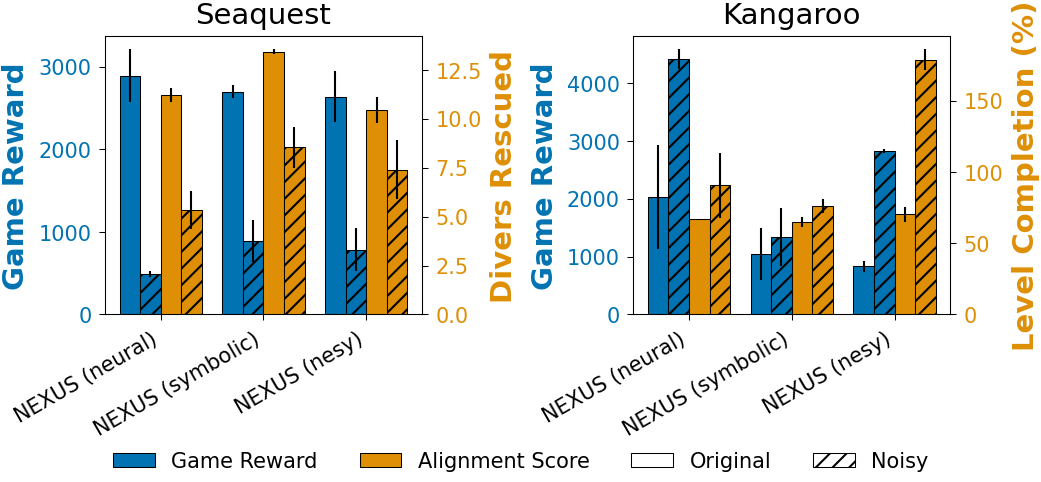

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

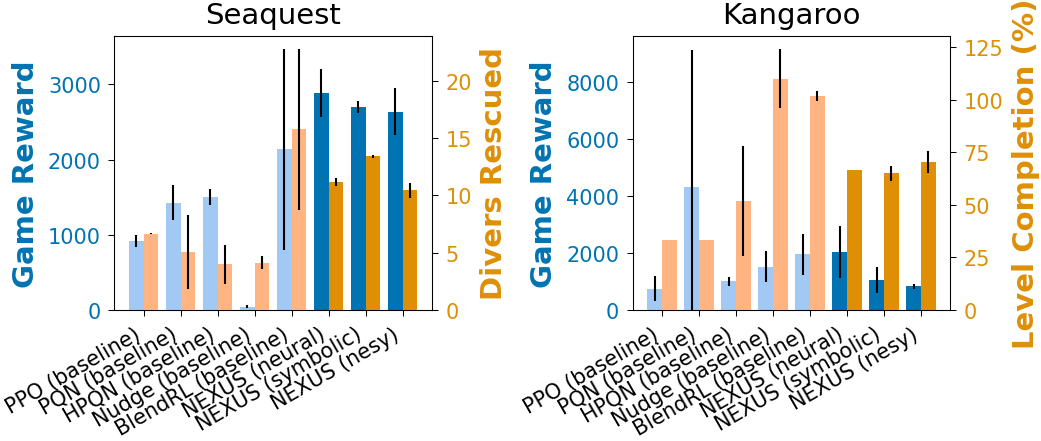

In [150]:
# Reproduce plot from above, but now with additional baselines NUDGE and BLENDRL
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    # fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    dual_metric_plot(all_seaquest_df, "Seaquest", ["ppo", "pqn","pqn_hier_baseline", "nudge", "blendrl", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb", ], ax[0])
    dual_metric_plot(all_kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "nudge", "blendrl", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    # plt.tight_layout()
    plt.savefig("all_baselines_comparison_dual_metric.pdf", bbox_inches="tight")
    plt.savefig("all_baselines_comparison_dual_metric.svg", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

ppo 3.0000001192092896 3.0
pqn 3.00000007947286 2.0
pqn_hier_baseline 4.666666746139526 3.0
nudge 28.222222222222225 356.88888888888886
Manual correction for nudge
blendrl 43.55555555555555 390.0
Manual correction for blendrl
pqn_hier 6.0 3.6666666666666665
pqn_hier_llm 6.853444576263428 8.797731717427572
pqn_hier_comb 6.333333810170491 3.0


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Times, TeX Gyre Termes, Nimbus Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, T

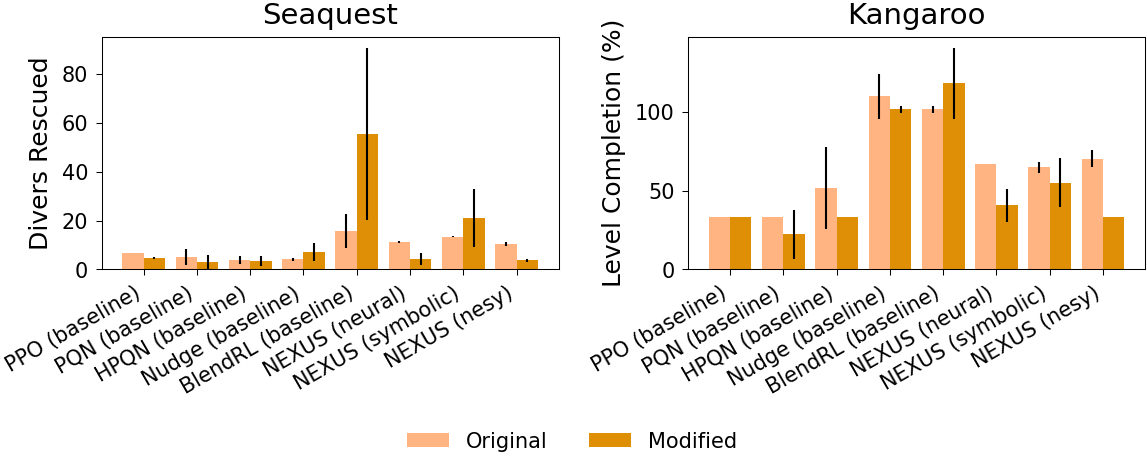

In [151]:
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    b1 = aligned_performance_drop_plot(all_seaquest_df, "Seaquest", ["ppo", "pqn", "pqn_hier_baseline", "nudge", "blendrl", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0])
    b2 = aligned_performance_drop_plot(all_kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "nudge", "blendrl", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    # b3 = aligned_performance_drop_plot(craftax_df, "Craftax-Classic-Symbolic-v1", ["pqn_rnn", "pqn_rnn_hier", "pqn_rnn_hier_llm", "pqn_rnn_hier_comb"], ax[2])
    fig.legend(labels=["Original", "Modified"], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.1)) 
    plt.tight_layout()
    plt.savefig("all_drop_plot.pdf", bbox_inches="tight")
    plt.show()

In [152]:



# 1. Define the LaTeX Header
# We use 'l' for left align (name) and 'c' for center align (data).
# The '||' creates the double vertical line visually.
table_header = r"""
\begin{table}[h]
\centering
\caption{Performance Comparison on Seaquest and Kangaroo}
\label{tab:nexus_results}
\resizebox{\textwidth}{!}{
\begin{tabular}{l | cc || cc}
\hline
\multirow{2}{*}{\textbf{Algorithm}} & \multicolumn{2}{c||}{\textbf{Seaquest}} & \multicolumn{2}{c}{\textbf{Kangaroo}} \\
 & Default (Divers Collected) & Simplification (Divers Collected) & Default (Level Completion) & Simplification (Level Completion) \\
\hline
"""

# 2. Define the Footer
table_footer = r"""
\hline
\end{tabular}
}
\end{table}
"""

# 3. Your Function (Slightly Modified)
def build_table_row(scores_sea, scores_kang, algo_name):
    row = f"{algo_name} & "
    # Seaquest Col 1
    row += f"{scores_sea[0]:.1f} $\\pm$ {scores_sea[1]:.1f} "
    row += f"({scores_sea[4]:.1f} $\\pm$ {scores_sea[5]:.1f}) & "
    # Seaquest Col 2
    row += f"{scores_sea[2]:.1f} $\\pm$ {scores_sea[3]:.1f} "
    row += f"({scores_sea[6]:.1f} $\\pm$ {scores_sea[7]:.1f}) & " # Changed || to &
    # Kangaroo Col 1
    row += f"{scores_kang[0]:.1f} $\\pm$ {scores_kang[1]:.1f} "
    row += f"({scores_kang[4]:.1f} $\\pm$ {scores_kang[5]:.1f}) & "
    # Kangaroo Col 2
    row += f"{scores_kang[2]:.1f} $\\pm$ {scores_kang[3]:.1f} "
    row += f"({scores_kang[6]:.1f} $\\pm$ {scores_kang[7]:.1f}) \\\\"
    return row

# 4. Assemble
table_content = ""
table_content += build_table_row(ppo_scores_sea, ppo_scores_kang, "PPO") + "\n"
table_content += build_table_row(pqn_scores_sea, pqn_scores_kang, "PQN") + "\n"
table_content += build_table_row(hpqn_scores_sea, hpqn_scores_kang, "NEXUS (neural)") + "\n"
table_content += build_table_row(llm_scores_sea, llm_scores_kang, "NEXUS (symbolic)") + "\n"
table_content += build_table_row(comb_scores_sea, comb_scores_kang, "NEXUS (nesy)") + "\n"
table_content += build_table_row(final_nudge_scores_sea, final_nudge_scores_kang, "NUDGE") + "\n"
table_content += build_table_row(final_blendrl_scores_sea, final_blendrl_scores_kang, "BlendRL") + "\n"
# manually add scobots
table_content += "SCoBots & 1055.3 $\pm$ 272.6 (- $\pm$ -) & 0.0 $\pm$ 0.0 (- $\pm$ -) & 2776.6 $\pm$ 1332.4 (- $\pm$ -) & 0.0 $\pm$ 0.0 (- $\pm$ -) \\\\\n"

# 5. Print Final Result
full_latex = table_header + table_content + table_footer
print(full_latex)



\begin{table}[h]
\centering
\caption{Performance Comparison on Seaquest and Kangaroo}
\label{tab:nexus_results}
\resizebox{\textwidth}{!}{
\begin{tabular}{l | cc || cc}
\hline
\multirow{2}{*}{\textbf{Algorithm}} & \multicolumn{2}{c||}{\textbf{Seaquest}} & \multicolumn{2}{c}{\textbf{Kangaroo}} \\
 & Default (Divers Collected) & Simplification (Divers Collected) & Default (Level Completion) & Simplification (Level Completion) \\
\hline
PPO & 915.3 $\pm$ 82.5 (6.7 $\pm$ 0.1) & 0.0 $\pm$ 0.0 (4.7 $\pm$ 0.5) & 750.0 $\pm$ 450.0 (33.3 $\pm$ 0.0) & 0.0 $\pm$ 0.0 (33.3 $\pm$ 0.0) \\
PQN & 1428.3 $\pm$ 232.1 (5.1 $\pm$ 3.2) & 0.0 $\pm$ 0.0 (3.0 $\pm$ 2.8) & 4300.0 $\pm$ 4833.2 (33.3 $\pm$ 0.0) & 200.0 $\pm$ 141.4 (22.2 $\pm$ 15.7) \\
NEXUS (neural) & 2887.6 $\pm$ 322.4 (11.2 $\pm$ 0.3) & 0.0 $\pm$ 0.0 (4.3 $\pm$ 2.5) & 2033.3 $\pm$ 899.4 (66.7 $\pm$ 0.0) & 666.7 $\pm$ 94.3 (40.7 $\pm$ 10.5) \\
NEXUS (symbolic) & 2697.1 $\pm$ 77.7 (13.4 $\pm$ 0.1) & 1853.3 $\pm$ 2621.0 (21.0 $\pm$ 11.8) & 1042.